## Seq2Seq2 번역기 만들기

- 프로젝트 루브릭

|학습목표|평가기준|
|---|---|
|테스트 결과 의미가 통하는 수준의 번역문이 생성되었다.|테스트용 디코더 모델이 정상적으로 만들어져서, 정답과 어느 정도 유사한 영어 번역이 진행됨을 확인하였다.|
|Attentional Seq2seq 모델이 정상적으로 구동된다.|seq2seq 모델 훈련 과정에서 training loss가 안정적으로 떨어지면서 학습이 진행됨이 확인되었다.|
|번역기 모델 학습에 필요한 텍스트 데이터 전처리가 한국어 포함하여 잘 이루어졌다.|구두점, 대소문자, 띄어쓰기, 한글 형태소분석 등 번역기 모델에 요구되는 전처리가 정상적으로 진행되었다.|

In [1]:
# 시각화를 위한 한글 폰트 설정
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
131 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 131 not upgraded.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [34]:
# Mecab 및 KoNLPy 설치
!pip install konlpy

In [35]:
!pip install mecab-python3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 6.3 MB/s eta 0:00:00


### 데이터 전처리

In [79]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [80]:
# 데이터 준비
import os
import urllib.request
import tarfile

# 데이터 준비
dataset_dir = os.path.expanduser("~/work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

# 데이터 다운로드
if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

# 압축 해제
if not os.path.exists(os.path.join(dataset_dir, "korean-english-park.train.ko")):
    print("압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=dataset_dir)
    print("압축 해제 완료!")

# 데이터 로드
path_ko = os.path.join(dataset_dir, "korean-english-park.train.ko")
path_en = os.path.join(dataset_dir, "korean-english-park.train.en")

with open(path_ko, "r", encoding="utf-8") as f:
    raw_ko = f.read().splitlines()

with open(path_en, "r", encoding="utf-8") as f:
    raw_en = f.read().splitlines()

print(f"원본 한국어 문장 수: {len(raw_ko)}")
print(f"원본 영어 문장 수: {len(raw_en)}")

원본 한국어 문장 수: 94123
원본 영어 문장 수: 94123


In [81]:
# 데이터 확인
print("🇰🇷 한국어 데이터 미리보기:")
for i in range(5):
    print(raw_ko[i])

print("\n🇺🇸 영어 데이터 미리보기:")
for i in range(5):
    print(raw_en[i])

🇰🇷 한국어 데이터 미리보기:
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
그러나 이것은 또한 책상도 필요로 하지 않는다.
79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.

🇺🇸 영어 데이터 미리보기:
Much of personal computing is about "can you top this?"
so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
Like all optical mice, But it also doesn't need a desk.
uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable to a terror attack.


In [82]:
# 데이터 정제
import re
from konlpy.tag import Mecab

# 1. 중복 데이터 제거
# set을 사용하되, 병렬 쌍(ko, en)이 흐트러지지 않도록 zip으로 묶어서 중복을 제거합니다.
raw_pairs = list(set(zip(raw_ko, raw_en)))
cleaned_ko, cleaned_en = zip(*raw_pairs)

print(f"중복 제거 후 문장 수: {len(cleaned_ko)}")

# 2. 데이터 전처리 함수 정의
mecab = Mecab()

def preprocess_sentence(sentence, s_type="en"):
    # 소문자 변환 및 양쪽 공백 제거
    sentence = sentence.lower().strip()

    # 구두점 띄어쓰기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 언어별 정규식 전처리
    if s_type == "en":
        # 영어: 알파벳과 구두점만 남김
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    elif s_type == "ko":
        # 한국어: 한글, 알파벳, 구두점만 남김
        sentence = re.sub(r"[^가-힣a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    # 토큰화 진행
    if s_type == "en":
        # 영어는 <start>, <end> 토큰 추가 후 띄어쓰기 기준 split
        sentence = f"<start> {sentence} <end>"
        return sentence.split()
    elif s_type == "ko":
        # 한국어는 Mecab을 이용한 형태소 분석
        return mecab.morphs(sentence)

# 3. 토큰화 및 길이 기반 필터링
kor_corpus = []
eng_corpus = []

for ko, en in zip(cleaned_ko, cleaned_en):
    tok_ko = preprocess_sentence(ko, s_type="ko")
    tok_en = preprocess_sentence(en, s_type="en")

    # 한국어와 영어 모두 토큰 길이가 40 이하인 경우만 저장
    if len(tok_ko) <= 40 and len(tok_en) <= 40:
        kor_corpus.append(tok_ko)
        eng_corpus.append(tok_en)

print(f"길이 40 이하 필터링 후 한국어 문장 수: {len(kor_corpus)}")
print(f"길이 40 이하 필터링 후 영어 문장 수: {len(eng_corpus)}")

# 확인용 샘플 출력
print("\n[한국어 코퍼스 샘플]")
print(kor_corpus[0])
print("\n[영어 코퍼스 샘플]")
print(eng_corpus[0])

중복 제거 후 문장 수: 78968
길이 40 이하 필터링 후 한국어 문장 수: 62733
길이 40 이하 필터링 후 영어 문장 수: 62733

[한국어 코퍼스 샘플]
['리처드', '베서', '미', '질병', '통제', '예방', '센터', 'cdc', '소장', '직무', '대행', '은', '폭스', '뉴스', '선데이', '에서', '이번', '바이러스', '로', '인해', '멕시코', '에서', '명', '이', '숨졌', '지만', ',', '병', '의', '강도', '가', '다른', '것', '은', '아니', '라고', '말', '했', '습니다', '.']

[영어 코퍼스 샘플]
['<start>', 'richard', 'besser', ',', 'tells', 'fox', 'news', 'sunday', 'even', 'though', 'people', 'have', 'been', 'killed', 'by', 'the', 'virus', 'in', 'mexico', ',', 'the', 'intensity', 'of', 'the', 'disease', 'may', 'be', 'the', 'same', '<end>']


In [83]:
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader

# 1. 토크나이저 클래스 정의
class Tokenizer:
    def __init__(self, corpus, vocab_size):
        self.vocab_size = vocab_size
        # 특수 토큰 미리 정의 (기존 모델의 설정값과 동일하게 맞춤)
        self.word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.idx2word = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        
        # 단어 빈도수 계산
        words = [word for sentence in corpus for word in sentence]
        word_counts = Counter(words)
        
        # 특수 토큰은 빈도수 계산에서 제외
        for token in ["<pad>", "<start>", "<end>", "<unk>"]:
            if token in word_counts:
                del word_counts[token]
                
        # 빈도수 상위 단어로 단어장 구축 (최소 10,000 이상 요구사항 충족)
        for idx, (word, _) in enumerate(word_counts.most_common(vocab_size - 4), start=4):
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            
    def encode(self, sentence):
        return [self.word2idx.get(word, self.word2idx["<unk>"]) for word in sentence]
        
    def decode(self, indices):
        # 패딩과 특수 토큰을 제외하고 문자열로 복원
        return " ".join([self.idx2word.get(idx, "<unk>") for idx in indices if idx not in [0, 1, 2]])

# 2. 단어장 크기 설정 (루브릭: 최소 10,000 이상)
VOCAB_SIZE = 15000

kor_tokenizer = Tokenizer(kor_corpus, VOCAB_SIZE)
eng_tokenizer = Tokenizer(eng_corpus, VOCAB_SIZE)

print(f"한국어 단어장 크기: {len(kor_tokenizer.word2idx)}")
print(f"영어 단어장 크기: {len(eng_tokenizer.word2idx)}")

# 3. 코퍼스를 정수 시퀀스로 변환 (텐서화)
kor_tensor = [kor_tokenizer.encode(s) for s in kor_corpus]
eng_tensor = [eng_tokenizer.encode(s) for s in eng_corpus]

print("\n[한국어 정수 인코딩 결과]")
print(kor_tensor[0])
print("\n[영어 정수 인코딩 결과]")
print(eng_tensor[0])

한국어 단어장 크기: 15000
영어 단어장 크기: 15000

[한국어 정수 인코딩 결과]
[2761, 3, 85, 1923, 970, 1644, 537, 4097, 1789, 5332, 7124, 10, 2862, 462, 4219, 19, 63, 1088, 24, 334, 938, 19, 30, 6, 674, 76, 20, 833, 9, 1996, 16, 95, 23, 10, 188, 39, 33, 13, 53, 4]

[영어 정수 인코딩 결과]
[1, 1671, 3, 6, 1628, 2682, 146, 116, 220, 705, 42, 27, 38, 104, 26, 4, 1781, 10, 1057, 6, 4, 5558, 8, 4, 719, 130, 30, 4, 295, 2]


In [84]:
# 4. 디코딩 결과 확인 (정수 시퀀스를 다시 텍스트로 복원)
print("\n[한국어 디코딩 결과]")
print(kor_tokenizer.decode(kor_tensor[0]))

print("\n[영어 디코딩 결과]")
print(eng_tokenizer.decode(eng_tensor[0]))

# 원본 코퍼스와 비교해보기
print("\n[비교용 원본 코퍼스]")
print("한국어:", " ".join(kor_corpus[0]))
print("영어:", " ".join(eng_corpus[0]))


[한국어 디코딩 결과]
리처드 <unk> 미 질병 통제 예방 센터 cdc 소장 직무 대행 은 폭스 뉴스 선데이 에서 이번 바이러스 로 인해 멕시코 에서 명 이 숨졌 지만 , 병 의 강도 가 다른 것 은 아니 라고 말 했 습니다 .

[영어 디코딩 결과]
richard <unk> , tells fox news sunday even though people have been killed by the virus in mexico , the intensity of the disease may be the same

[비교용 원본 코퍼스]
한국어: 리처드 베서 미 질병 통제 예방 센터 cdc 소장 직무 대행 은 폭스 뉴스 선데이 에서 이번 바이러스 로 인해 멕시코 에서 명 이 숨졌 지만 , 병 의 강도 가 다른 것 은 아니 라고 말 했 습니다 .
영어: <start> richard besser , tells fox news sunday even though people have been killed by the virus in mexico , the intensity of the disease may be the same <end>


In [85]:
class TranslationDataset(Dataset):
    def __init__(self, src_data, trg_data, max_len):
        self.src_data = src_data
        self.trg_data = trg_data
        self.max_len = max_len
        self.pad_id = 0

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        src_ids = self.src_data[idx]
        trg_ids = self.trg_data[idx]

        # 디코더의 input은 <end> 토큰 제외 (마지막 토큰 빼기)
        trg_input = trg_ids[:-1]
        # 디코더의 label은 <start> 토큰 제외 (첫 번째 토큰 빼기)
        trg_label = trg_ids[1:]

        # 길이에 맞춰 패딩(<pad>: 0) 추가
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

# 최대 길이 설정 (Step 2에서 40으로 필터링했으므로 40 사용)
MAX_LEN = 40
BATCH_SIZE = 64

# 루브릭 요구사항: "데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지는 않습니다."
# 따라서 전체 데이터를 모두 Train으로 사용합니다.
train_dataset = TranslationDataset(kor_tensor, eng_tensor, max_len=MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 텐서 shape 확인
for src, trg_input, trg_label in train_loader:
    print(f"Source shape: {src.shape}")
    print(f"Target Input shape: {trg_input.shape}")
    print(f"Target Label shape: {trg_label.shape}")
    break

Source shape: torch.Size([64, 40])
Target Input shape: torch.Size([64, 40])
Target Label shape: torch.Size([64, 40])


### 모델 설계

In [86]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [87]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [88]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [89]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [90]:
# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 파라미터 설정 (우리가 방금 만든 토크나이저의 단어장 크기 사용)
input_dim = len(kor_tokenizer.word2idx)
output_dim = len(eng_tokenizer.word2idx)
emb_dim = 256
hid_dim = 512

# 모델 생성
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(15000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(15000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=15000, bias=True)
  )
)


### 모델 훈련

In [91]:
# optimizer, loss설정
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [56]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

In [92]:
def evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    # 한국어 전처리 (Mecab 형태소 분석 포함)
    tok_sentence = preprocess_sentence(sentence, s_type="ko")

    # 정수 인코딩 및 텐서 변환
    src_ids = kor_tokenizer.encode(tok_sentence)
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        # 추론 시에는 디코더의 입력(trg)을 주지 않음
        outputs, _ = model(src_tensor, max_len=max_len)

    # 확률이 가장 높은 단어의 인덱스 추출
    pred_indices = outputs.argmax(2).squeeze(1).tolist()
    
    # 인덱스를 텍스트로 디코딩
    result_sentence = eng_tokenizer.decode(pred_indices)

    # <end> 토큰이 나오면 그 뒤의 텍스트는 잘라냄
    if "<end>" in result_sentence:
        result_sentence = result_sentence.split("<end>")[0].strip()

    return result_sentence

In [57]:
# 매 스텝 번역 생성을 위한 추론 함수 (새로운 Tokenizer에 맞게 수정)
def evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    # 한국어 전처리 (Mecab 형태소 분석 포함)
    tok_sentence = preprocess_sentence(sentence, s_type="ko")

    # 정수 인코딩 및 텐서 변환
    src_ids = kor_tokenizer.encode(tok_sentence)
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        # 추론 시에는 디코더의 입력(trg)을 주지 않음
        outputs, _ = model(src_tensor, max_len=max_len)

    # 확률이 가장 높은 단어의 인덱스 추출
    pred_indices = outputs.argmax(2).squeeze(1).tolist()
    
    # 인덱스를 텍스트로 디코딩
    result_sentence = eng_tokenizer.decode(pred_indices)

    # <end> 토큰이 나오면 그 뒤의 텍스트는 잘라냄
    if "<end>" in result_sentence:
        result_sentence = result_sentence.split("<end>")[0].strip()

    return result_sentence

In [59]:
EPOCHS = 20
sample_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'\nEpoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')
    
    # 훈련 중 모델이 어떻게 번역하는지 테스트
    print('모델 번역 시도:')
    for sentence in sample_sentences:
        translation = evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer)
        print(f" - 입력: {sentence}")
        print(f" - 번역: {translation}")
    print("-" * 50)

Epoch 1: 100%|██████████| 981/981 [04:16<00:00,  3.82it/s, loss=4.62]



Epoch 1/20, Train Loss: 4.6037
모델 번역 시도:
 - 입력: 오바마는 대통령이다.
 - 번역: obama is president obama .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: they are <unk> in the city .
 - 입력: 커피는 필요 없다.
 - 번역: the need is not enough to make sure
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: the death toll from the scene , the death toll from the scene .
--------------------------------------------------


Epoch 2: 100%|██████████| 981/981 [04:15<00:00,  3.83it/s, loss=3.55]



Epoch 2/20, Train Loss: 3.6508
모델 번역 시도:
 - 입력: 오바마는 대통령이다.
 - 번역: obama s inauguration .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: they re gonna cities in cities across the city .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is the need for the need for the need to go .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: the death toll was killed .
--------------------------------------------------


Epoch 3: 100%|██████████| 981/981 [04:15<00:00,  3.84it/s, loss=3.18]


...


Epoch 18/20, Train Loss: 0.6188
모델 번역 시도:
 - 입력: 오바마는 대통령이다.
 - 번역: obama s president is going to president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: of them
 - 입력: 커피는 필요 없다.
 - 번역: the need for cnn .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven deaths were killed .
--------------------------------------------------


Epoch 19: 100%|██████████| 981/981 [04:15<00:00,  3.84it/s, loss=0.64] 



Epoch 19/20, Train Loss: 0.5959
모델 번역 시도:
 - 입력: 오바마는 대통령이다.
 - 번역: obama will be president obama .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens entering the highest capital city city amid growing warnings in the city amid growing security .
 - 입력: 커피는 필요 없다.
 - 번역: this does not need an extra flight .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven people were killed .
--------------------------------------------------


Epoch 20: 100%|██████████| 981/981 [04:15<00:00,  3.84it/s, loss=0.705]


Epoch 20/20, Train Loss: 0.5764
모델 번역 시도:
 - 입력: 오바마는 대통령이다.
 - 번역: obama s president is going to go .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: of them , in these cities !
 - 입력: 커피는 필요 없다.
 - 번역: coffee needs intelligence need do not meet .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven people were killed .
--------------------------------------------------


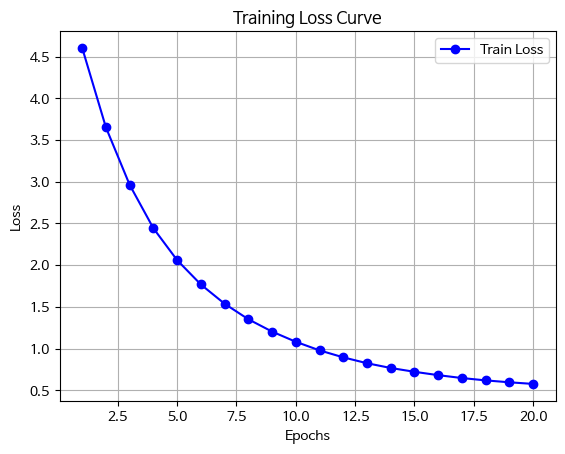

In [62]:
import matplotlib.pyplot as plt

def plot_loss_curve(losses):
    epochs = range(1, len(losses) + 1)
    plt.plot(epochs, losses, label='Train Loss', color='blue', marker='o')
    
    # 그래프 제목 및 축 라벨 설정 (LaTeX formatting 적용)
    plt.title('Training Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    
    # 범례 및 그리드 추가
    plt.legend()
    plt.grid(True)

    plt.show()

train_losses = [4.6037,3.6508,2.9624,2.4420,2.0600,1.7682,1.5374,1.3516 ,1.2036 ,1.0816 ,0.9786 ,0.8949 ,0.8245 ,0.7674 ,0.7217 ,0.6815 ,0.6469 ,0.6188 ,0.5959,0.5764]

#시각화 함수 호출
plot_loss_curve(train_losses)

### 모델 평가

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    # x축: 입력한 한국어 문장 (Mecab 형태소 단위)
    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    # y축: 번역된 영어 문장
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

def translate_and_show_attention(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    # 1. 한국어 전처리 (Mecab)
    tok_sentence = preprocess_sentence(sentence, s_type="ko")
    
    # 2. 텐서 변환
    src_ids = kor_tokenizer.encode(tok_sentence)
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        # 3. 모델 추론 (어텐션 값도 함께 받아옴)
        outputs, attentions = model(src_tensor, max_len=max_len)

    # 4. 결과 디코딩
    pred_indices = outputs.argmax(2).squeeze(1).tolist()
    
    # <end> 토큰 전까지만 잘라내기
    if 2 in pred_indices: # 2는 <end> 토큰의 인덱스
        pred_indices = pred_indices[:pred_indices.index(2)]
        
    result_sentence = [eng_tokenizer.idx2word.get(idx, "<unk>") for idx in pred_indices if idx not in [0, 1]]

    print('Input:', " ".join(tok_sentence))
    print('Predicted translation:', " ".join(result_sentence))

    # Attention Map 크기 조절 (출력길이 x 입력길이)
    attention = attentions.squeeze(1).cpu().numpy()
    attention = attention[:len(result_sentence), :len(tok_sentence)]

    plot_attention(attention, tok_sentence, result_sentence)

Input: 오바마 는 대통령 이 다 .
Predicted translation: obama s president is going to go .


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


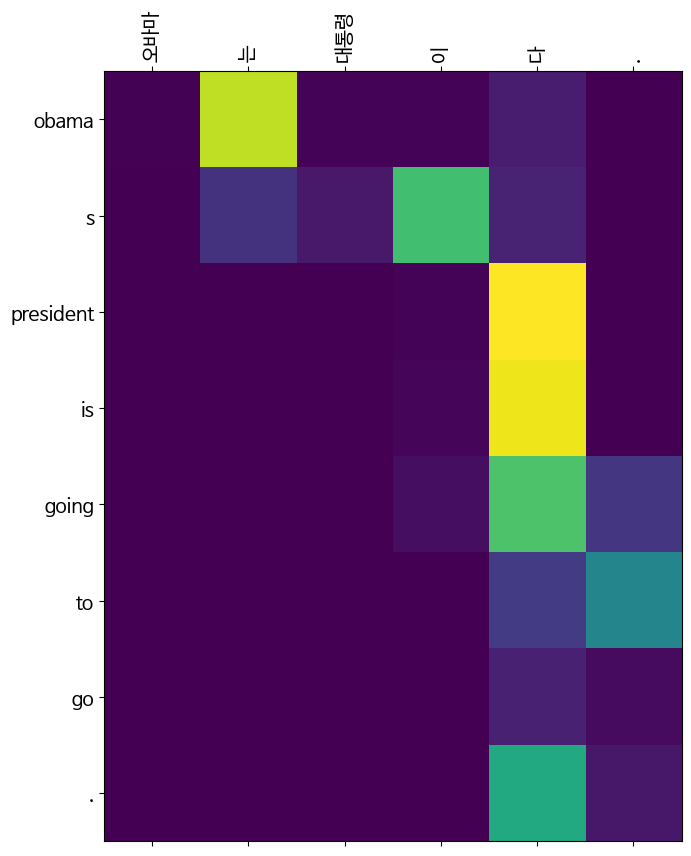

--------------------------------------------------
Input: 시민 들 은 도시 속 에 산다 .
Predicted translation: of them , in these cities !


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


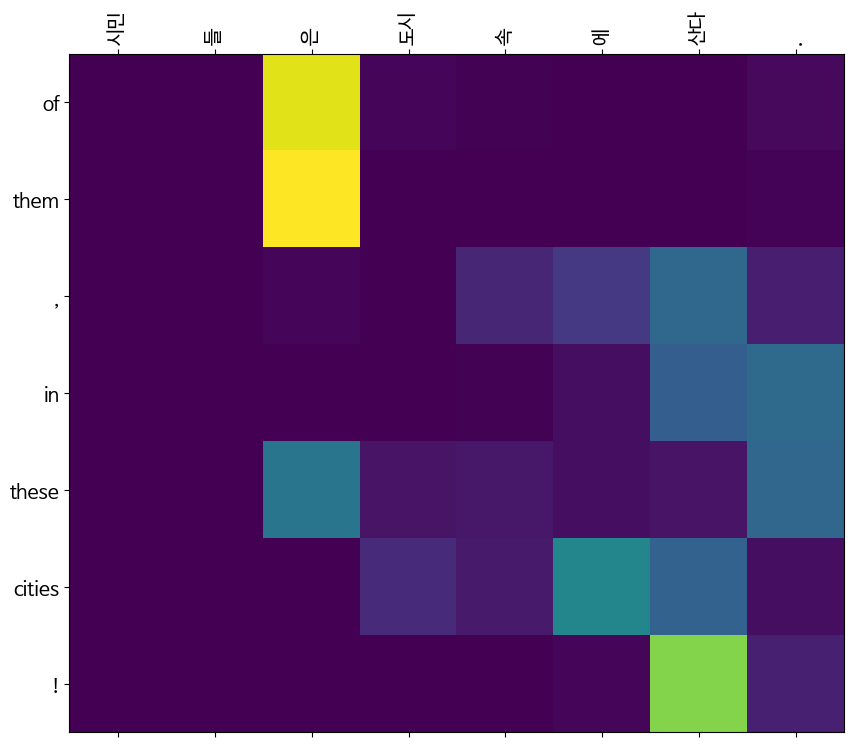

--------------------------------------------------
Input: 커피 는 필요 없 다 .
Predicted translation: coffee needs intelligence need do not meet .


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


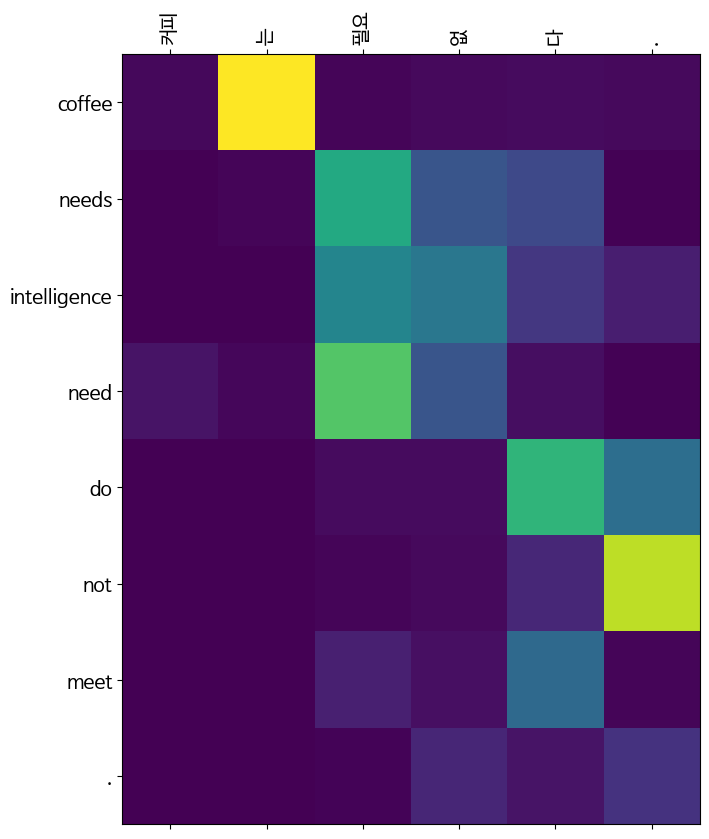

--------------------------------------------------
Input: 일곱 명 의 사망자 가 발생 했 다 .
Predicted translation: seven people were killed .


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


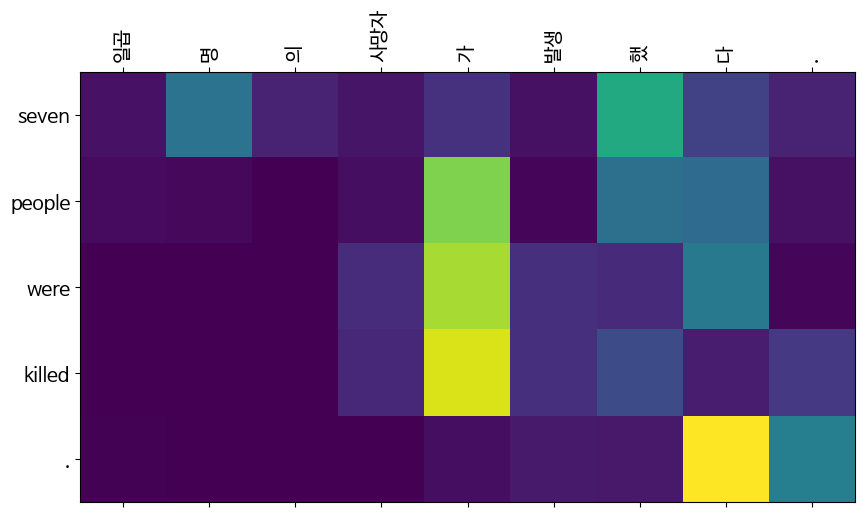

--------------------------------------------------


In [64]:
# 루브릭에서 요구하는 4개 예문 테스트
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for s in test_sentences:
    translate_and_show_attention(s, model, kor_tokenizer, eng_tokenizer)
    print("-" * 50)

Input: 정부 는 새로운 정책 을 발표 했 다 .
Predicted translation: the government unveiled tests policies policy to new policy toward the new policy .


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


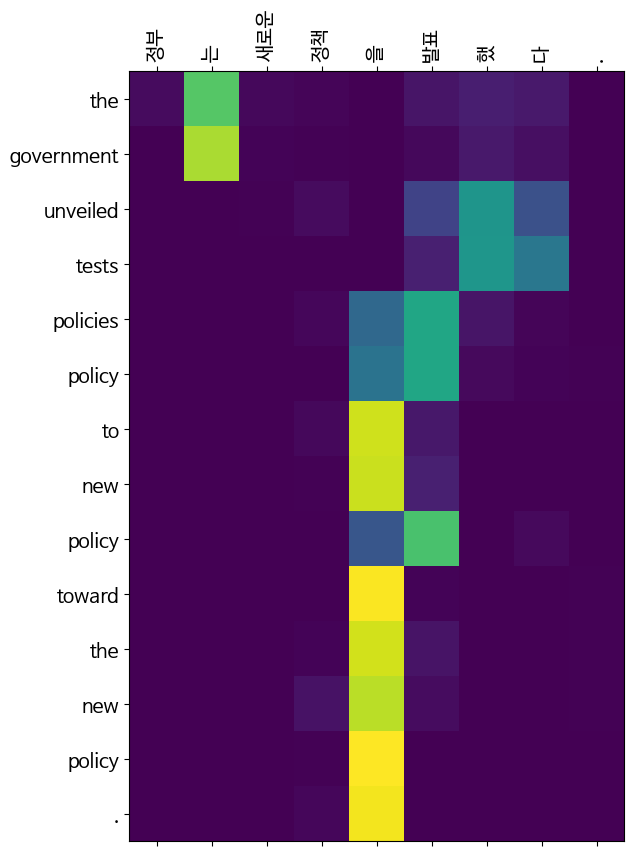

--------------------------------------------------
Input: 경찰 은 사건 을 조사 하 고 있 다 .
Predicted translation: police are investigating the incident .


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


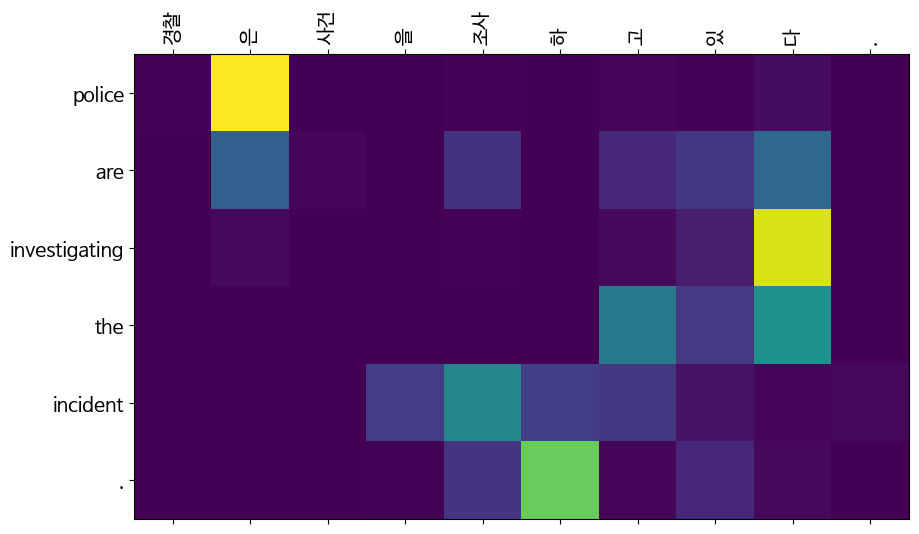

--------------------------------------------------
Input: 시민 들 이 거리 에 모였 다 .
Predicted translation: on wednesday , the impeachment went on to try to pay lobbyists .


/tmp/ipykernel_528/402872718.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_528/402872718.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


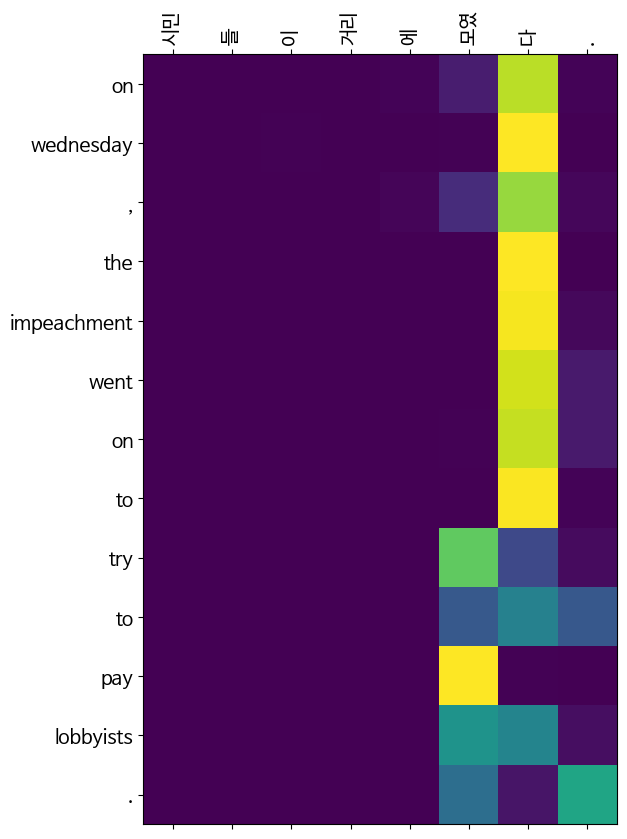

--------------------------------------------------


In [65]:
# 추가 예문 테스트
test_sentences = [
    "정부는 새로운 정책을 발표했다.",
    "경찰은 사건을 조사하고 있다.",
    "시민들이 거리에 모였다.",
]

for s in test_sentences:
    translate_and_show_attention(s, model, kor_tokenizer, eng_tokenizer)
    print("-" * 50)

### 결과 정리

#### 0. 사용한 데이터셋 분석 - [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)
  - 뉴스 도메인
    - 특정 패턴이 반복된다.
  - 데이터 크기
    - 원본: 94123
    - 정제 후: 62733
    > **실습용으로는 충분하지만 Robust하지는 않다**  
    repetition(반복현상), semantic drift(의미이탈), hallucination(환각현상) 이 잘 발생한다고 함
  - 데이터 품질: github 이슈 중 일부 번역 pair의 정합성 문제와 중복 문장 문제, 데이터 오염 문제가 제기된 기록이 있음  
    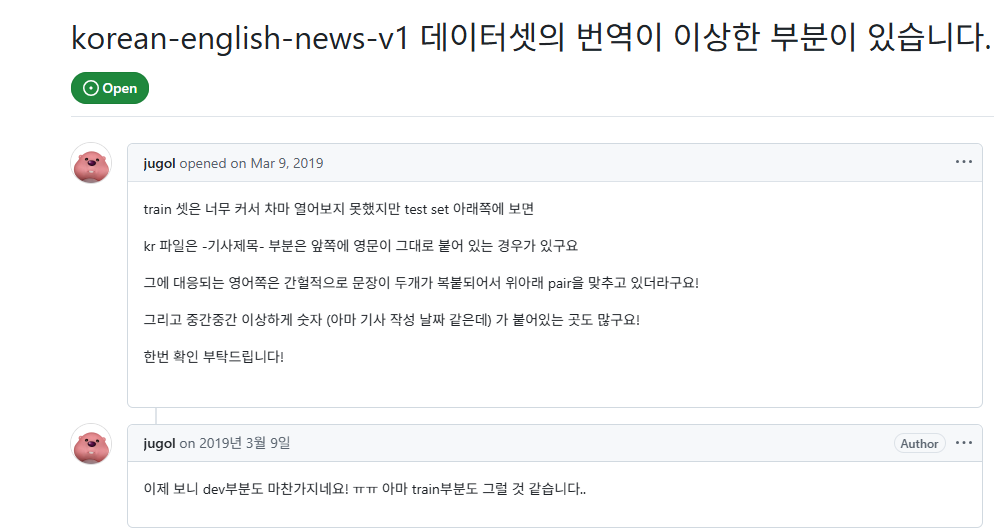

#### 1. lr curve  

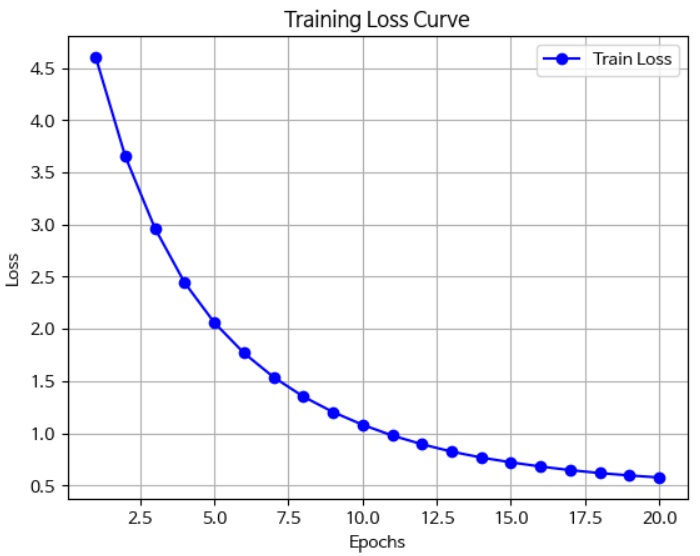

#### 2. 매 에폭별 정성평가

|Epoch|오바마는 대통령이다| 시민들은 도시 속에 산다|커피는 필요 없다| 일곱 명의 사망자가 발생했다|
|---|---|---|---|---|
|1|obama is president obama|they are `<unk>` in the city|the need is not enough to make sure|the death toll from the scene|
|2|obama s inauguration|they re gonna cities in cities across the city|coffee is the need for the need for the need to go|the death toll was killed|
|3|obama is aiming for president|citizens are `<unk>`|the need for the need for the need to do|the death toll was killed|
|4|obama s inauguration , president obama , is in the fall|citizens in cities|coffee is the need to do things|the death toll was|
|5|obama is the president| spectators are everywhere| it s not necessarily the necessary| the death toll was|
|6| obama is a president| citizens of the city s `<unk>` cities| coffee is asking for the need to be `<unk>`| the death toll was|
|7| obama will be president obama| citizens entering the city s streets| coffee is asking for the need to be `<unk>`| seven deaths were reported|
|8| obama s president is | citizens of the city s | coffee is the need to do necessary | the death toll was|
|9| obama is the president| of them , it s kind of like| coffee is asking the way for coffee| deaths were killed|
|10| obama is going to be president| citizens entering the city streets| the need for the coffee needs to be| the death toll was|
|11| obama will be president obama| citizens entering the city| coffee needs cnn at the same time it coffee without necessary | seven of the dead were people s death |
|12| obama s president is going to president| citizens entering the city streets| coffee needs to need the need for coffee needs| seven deaths were killed|
|13| obama is going to president barack obama| citizens of the city s inner city| and don t need coffee to do necessary| seven people were killed |
|14| obama is the president| citizens of the city s main city| the need for home prices| seven people were killed|
|15| obama is the president| citizens entering the city streets| the need for his current height | seven deaths were killed|
|16| obama s president is campaigning in| citizens entering the highest city| coffee is the same buyer not| seven deaths were each|
|17| obama is the president | citizens of the city s main city| store need to do it down | seven people were killed|
|18| obama s president is going to president| of them| the need for cnn| seven deaths were killed|
|19| obama will be president obama| citizens entering the highest capital city city amid growing warnings in the city amid growing security | this does not need an extra flight | seven people were killed|
|20| obama s president is going to go| of them , in these cities| coffee needs intelligence need do not meet| seven people were killed|

- 모범 답안 
  E1) obama is the president .  
  E2) people are victims of the city .-> People/Citizens live in the city.  
  E2) the price is not enough -> Coffee is not necessary.  
  E2) seven people have died .  
- 가장 잘 번역한 Case  
  E1) obama is the president (Epoch: 5, 9, 14, 15, 17)  
  E2) citizens in cities (Epoch: 4)  
  E3) 솔직히 없다.   
  > the need is not enough to make sure 처럼 필요하지 않다라는 '부정 의미'를 갖추면 'coffee(핵심단어)'가 빠져있고,  
  > coffee가 들어가면 coffee is the need to do things 처럼 반대 의미를 나타내는 경우들, 아예 문장 성립이 안되는 출력이 관찰됨
  
  E4) seven people were killed (Epoch: 13, 14, 17, 19, 20)

#### 3. 20 epoch 학습 후 attention map 시각화 결과
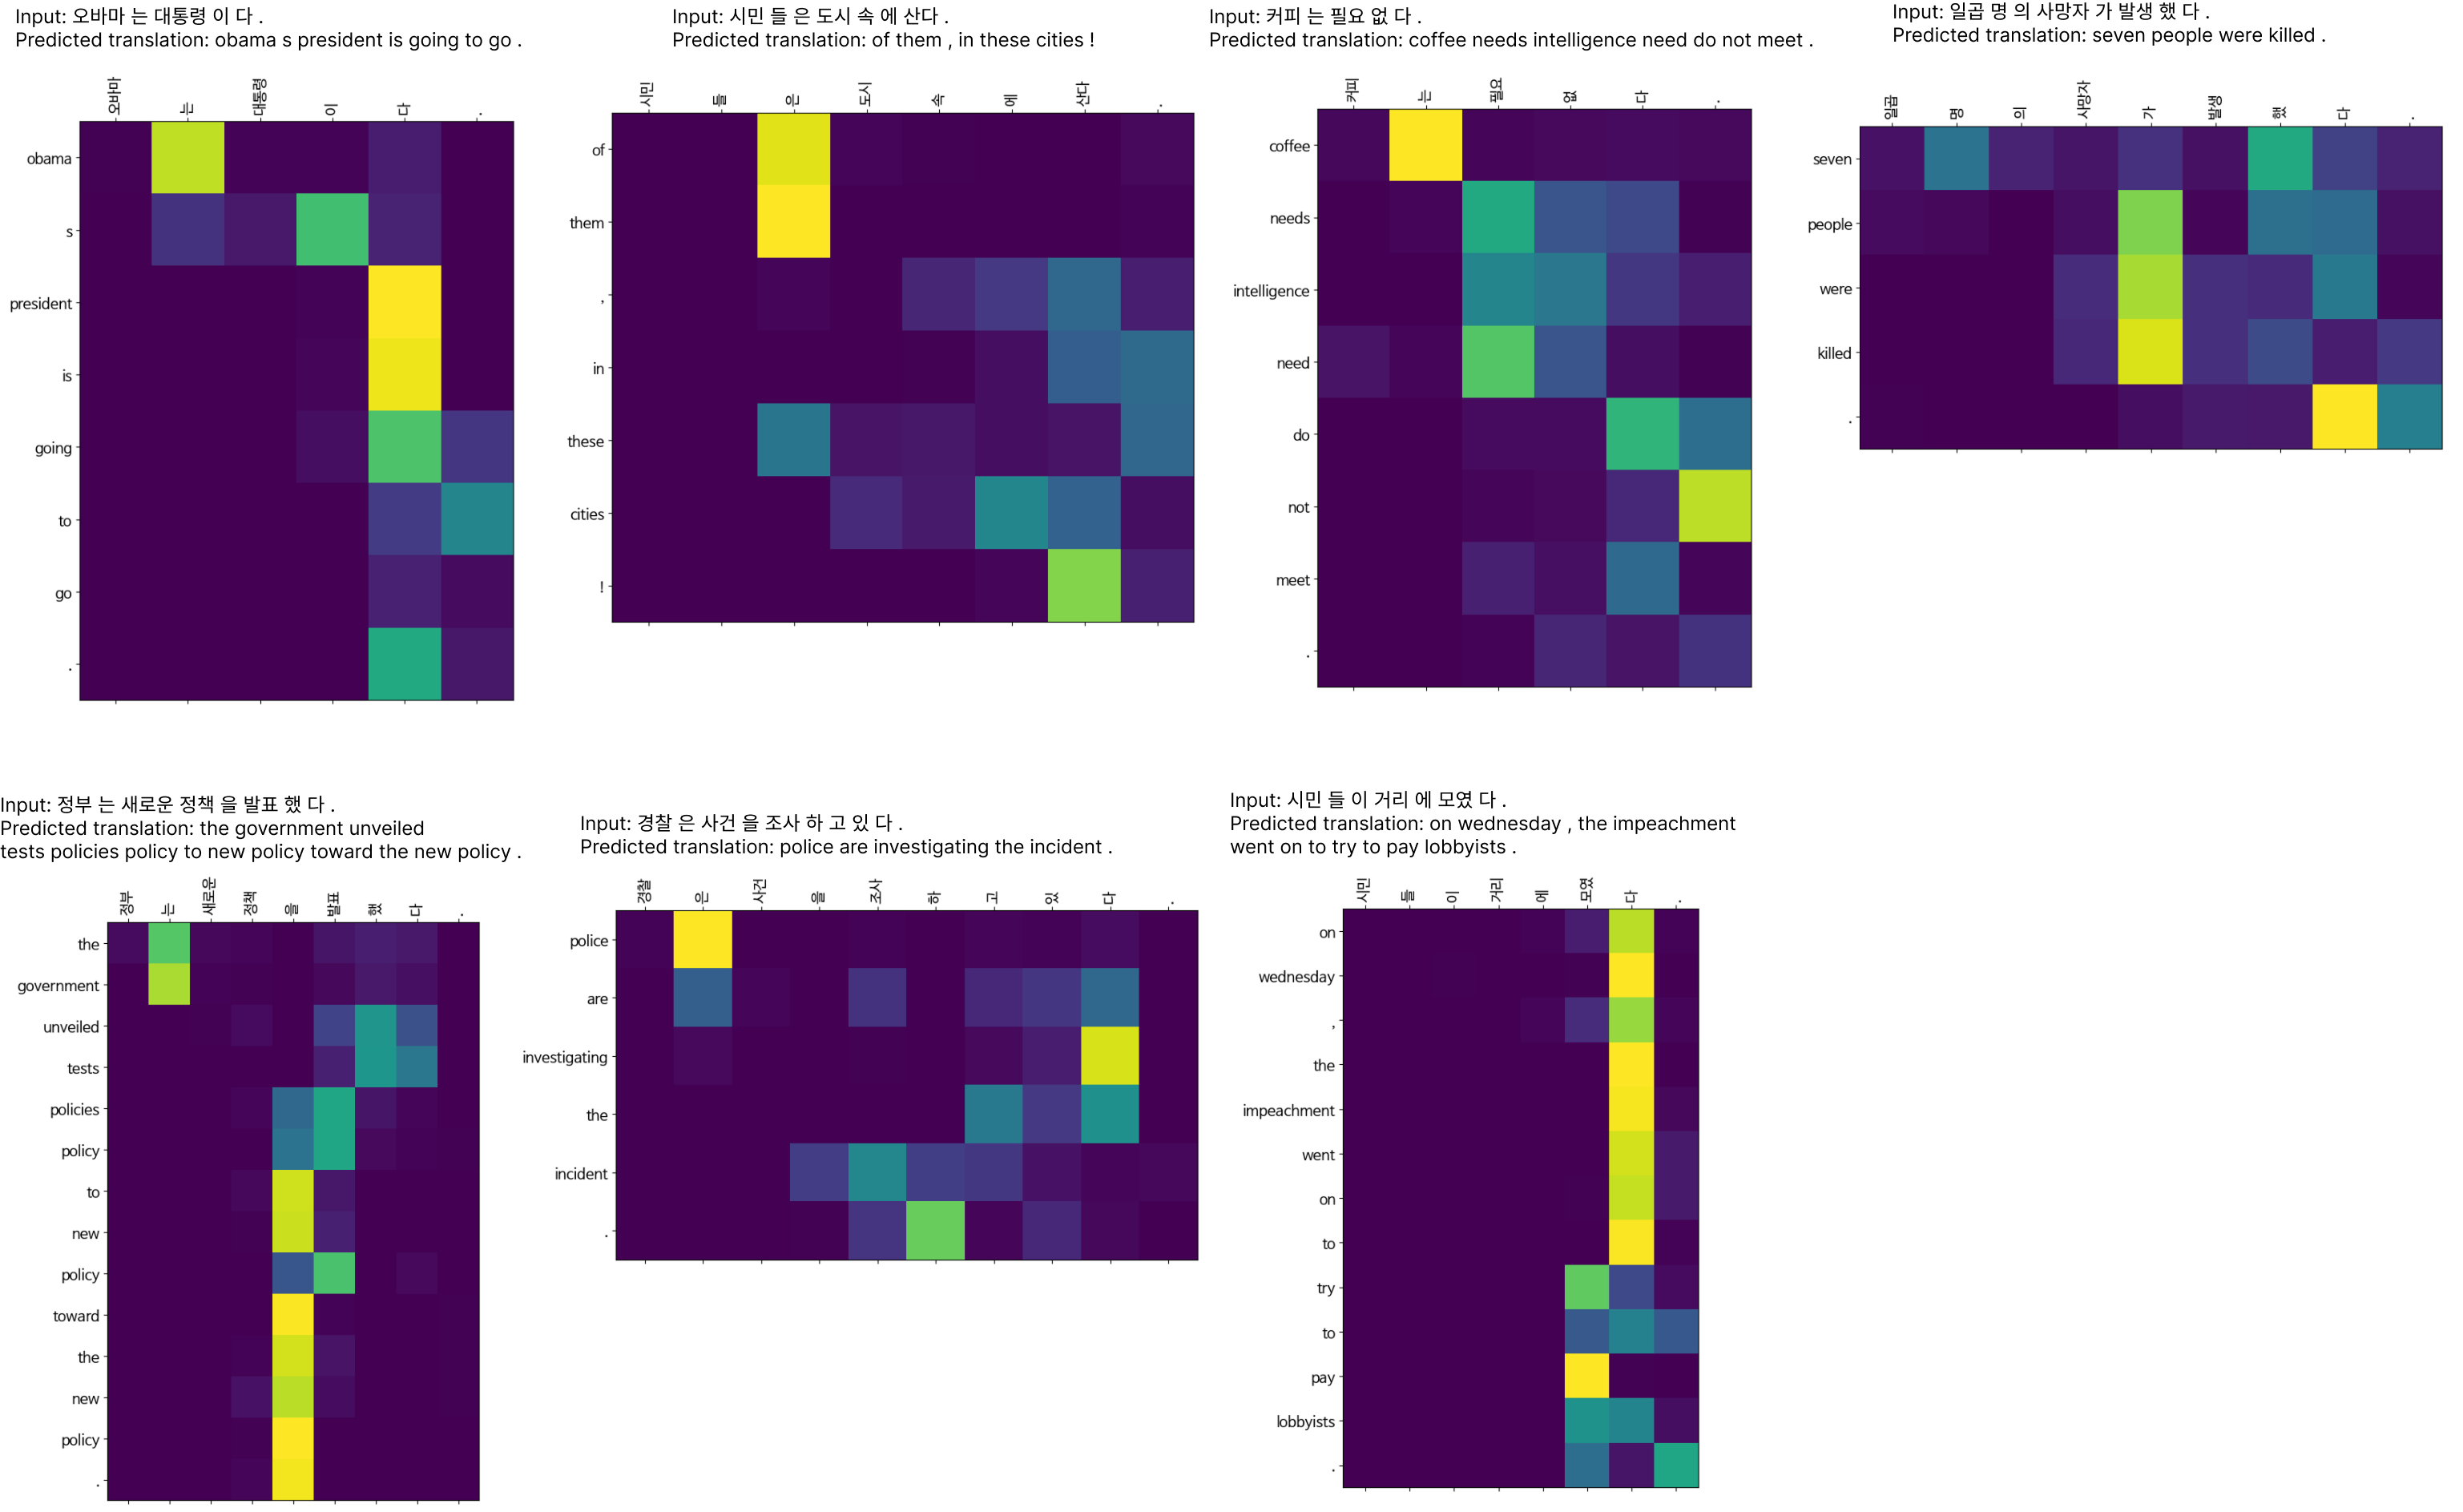
중심 단어에 attention을 하지못하고 특정 조사 및 일부 위치에 attention이 집중되는 현상이 관찰됨.
- 특히, 일부 문장에서는 attention weight가 특정 column에 수직 띠(vertical banding) 형태로 몰리는 현상이 나타남.
  이는 decoder가 특정 입력 토큰만을 반복적으로 참조하고 있는 것으로, **입력 문장의 의미적 대응 관계를 충분히 학습하지 못했다는 의미**
- 찾아보니, 3가지 개념으로 연결지을 수 있었다.
  - 허브 토큰 현상: 번역기가 단어를 하나하나 매칭해서 번역하는 것을 포기하고, 마침표나 조사 같은 단어 하나에 모든 정보를 몰아넣고 멍하니 쳐다보는 상태
    마침표가 마치 모든 교통이 몯이는 '허브(hub) 역'처럼 변해버려서, 정작 중요한 단어 간의 연결 고리를 놓치게 된다.
  - 디코더의 언어 모델화: 디코더가 한국어 원문은 아예 무시하고, 자기가 아는 영어 문법만 가지고 소설을 쓰는 상태
    결과적으로, Hallucination이 발생
  - 어텐션 붕괴: 모델이 문장이 너무 길거나 노이즈가 많아서 어디를 봐야할지 전혀 감을 못 잡는 상태

- 추가적인 3개 test 문장의 결과 확인
  > Input: 정부 는 새로운 정책 을 발표 했 다 . 
Predicted translation: the government unveiled tests policies policy to new policy toward the new policy .
  > Input: 경찰 은 사건 을 조사 하 고 있 다 . 
Predicted translation: police are investigating the incident .
  > Input: 시민 들 이 거리 에 모였 다 . 
Predicted translation: on wednesday , the impeachment went on to try to pay lobbyists .

#### 4. 결론
우선, 모델 학습 결과 train loss는 지속적으로 감소하였으나 번역 품질은 오히려 저하되는 현상이 관찰되었다.  
특히 뒤로 갈수록 아예 문장 성립이 안되거나 hallucination이 심한 현상을 확인할 수 있었다.  
Attention map 분석 결과, 일부 문장에서 특정 조사 및 문장 끝(마침표)에 attention이 집중되는 vertical banding 현상이 확인되어 디코더가 제대로 단어들의 관계를 파악하지 못하고 마음대로 문장을 생성한다는 것을 확인하였다.  
마지막으로 test 문장들의 번역 결과를 봤을 때, 뉴스에 자주 나올만한 주제는 비슷하게라도 생성이 되었지만 자주 나오지 않을 주제(커피)에 대해서는 이상한 문장들을 생성하였다. 또한, 추가로 test한 문장 중 '시민들이 거리에 모였다.'라는 문장이 있었는데 시위 관련으로 보면 뉴스에 나올 수 있는 문장이지만 이또한 환각현상이 심하게 발생한 것을 볼 수 있었다.  

**loss와 번역 품질의 상관관계가 크지 않음을 보여주는 실험 결과였고, 데이터셋의 한계도 영향을 주었으리라는 생각이 들었다.  
20 epoch에서의 성능이 최적이 아닌 것으로 생각되는데, attention map을 20 epoch에서만 출력해볼 수 있어 아쉬웠다.**

### ablation study 설계

1. 정성적 평가를 통한 best epoch 찾기  
baseline 실험에서 20epoch이 best가 아닌 것을 관찰했는데, 정성적 평가를 통한 번역 품질이 가장 최적인 epoch에서의 attention map을 관찰하고 싶었다.

2. 데이터 정제 강화 (문장 길이 40 -> 30)
어텐션 붕괴 현상을 해결하기 위한 방법 중 데이터 정제를 강화하여 좀 더 모델이 학습하기에 편리하도록 해당 실험을 설계하였다.

3. dropout 추가 (p=0.5)
한정된 규모의 데이터셋에 과적합되는 현상을 완화하기 위한 방안으로 설계하였다.

4. learning rate 변경 (1e-3 -> 5e-4)
과도한 학습으로 인한 불안정한 수렴 가능성을 줄이고, 보다 안정적인 학습을 유도하기 위해 설계하였다.

5. beam search 적용
  - greedy search: 매 순간 가장 확률이 높은 단어 하나만 선택
  - beam search: 여러 가지 가능성을 동시에 고려

|실험 번호|핵심 변경점|기대 효과|분석 포인트|
|---|---|---|---|
|Baseline|**기본 설정 (20 Epoch)**|기준점 확보|Loss 하강 곡선 확인|
|추가실험 1|**Best Epoch 찾기**|정성적 최적화|Loss와 번역 품질의 상관관계|
|추가실험 2|**데이터 정제 강화**|노이즈 제거|짧은 문장에서의 어텐션 정확도|
|추가실험 3|**Dropout 추가**|과적합 방지|수직 띠(Vertical Banding) 완화 여부|
|추가실험 4|**LR Tuning(5e-4)**|정교한 학습|최종 Loss 수렴 값의 안정성|
|추가실험 5|**Beam Search**|추론 품질 향상|Greedy 방식 대비 문장의 매끄러움|

>추가 실험 2~5는 baseline과의 공정한 비교를 위해 epoch 수는 동일하게 20으로 유지하였다.

In [93]:
from tqdm import tqdm
import torch

def train_step(model, loader, optimizer, criterion, epoch):
    model.train()
    running_loss = 0
    
    # tqdm 진행률 바 추가 (답답함 해소!)
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}", leave=False)
    
    for src, trg_input, trg_label in progress_bar:
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()
        
        # 모델 예측
        output, _ = model(src, trg_input)
        
        # Loss 계산을 위해 차원 변경 (안전한 reshape 사용)
        output = output.reshape(-1, output.shape[-1])
        trg_label = trg_label.reshape(-1)
        
        loss = criterion(output, trg_label)
        loss.backward()
        
        # Gradient Clipping (새 코드의 좋은 점 유지)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        
        # 진행률 바 옆에 실시간 Loss 표시
        progress_bar.set_postfix(loss=loss.item())
        
    # 에포크 전체의 평균 Loss 반환
    epoch_loss = running_loss / len(loader)
    return epoch_loss

In [94]:
# [공통] 시각화를 위한 샘플 문장 리스트 정의
sample_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

#### 실험 1. 정성적 평가를 통해 가장 성능이 좋았던 Epoch

_(시작 전에 위에 있는 학습 전 준비 셀(데이터로더, 모델 생성 등 포함) 다시 실행하였습니다.)_

In [95]:
# [실험 1]
# 시각화를 위해 Loss를 담을 리스트
train_losses_baseline = [] 

EPOCHS = 20

for epoch in range(EPOCHS):
    # 1. 학습 진행 및 에포크 Loss 수집
    avg_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses_baseline.append(avg_loss) # 리스트에 저장 (시각화용)
    
    # 2. 실험 1을 위한 모델 저장 (매 에포크 가중치 기록)
    # 나중에 정성적으로 좋았던 에포크를 골라 model.load_state_dict() 하면 됩니다.
    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}')
    
    # 3. 정성적 확인 (매 에포크 결과 출력)
    print(f"[Epoch {epoch+1} 실험 1 번역 테스트]")
    for sentence in sample_sentences:
        translation = evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer)
        print(f" - 입력: {sentence}")
        print(f" - 번역: {translation}")
    print("-" * 50)

Epoch 1/20, Avg Loss: 5.1318
[Epoch 1 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: obama s president barack obama is in the oval .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: they were in the city of <unk> .
 - 입력: 커피는 필요 없다.
 - 번역: the <unk> is not a good thing .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: the death toll from the death toll , the death toll .
--------------------------------------------------


Epoch 2/20, Avg Loss: 3.9187
[Epoch 2 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is poised to be sworn for president obama .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: the city is in cities for cities .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is not need to need to the need for the need to need to need to need to need to need to need to need to need to need to need to need to need to need to need
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: a total of people died in the clashes .
--------------------------------------------------


Epoch 3/20, Avg Loss: 3.1634
[Epoch 3 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is poised to see the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens , the city s urban <unk> is in cities .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is not necessary .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: the death toll was .
--------------------------------------------------


Epoch 4/20, Avg Loss: 2.5892
[Epoch 4 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens of cities , the city s sacred cities was taken off the city of <unk> .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is not necessary .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven deaths were killed .
--------------------------------------------------


Epoch 5/20, Avg Loss: 2.1691
[Epoch 5 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens , they re in the hands of the city .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is needed for your period .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven deaths were killed .
--------------------------------------------------


...

Epoch 16/20, Avg Loss: 0.6915
[Epoch 16 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens of the city taken in .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is not necessarily necessary .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven deaths were reported .
--------------------------------------------------


Epoch 17/20, Avg Loss: 0.6574
[Epoch 17 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: president obama has means he ll come with president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens of women and men .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is there though no need for is needed .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven deaths were reported .
--------------------------------------------------


Epoch 18/20, Avg Loss: 0.6278
[Epoch 18 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: president obama has means the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens , they re in good city .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is the need for coffee and another .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven people were killed .
--------------------------------------------------


Epoch 19/20, Avg Loss: 0.6029
[Epoch 19 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: president obama has means the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens of the city streets and the city .
 - 입력: 커피는 필요 없다.
 - 번역: coffee without the coffee are necessary , but we are without another saying .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven deaths were reported .
--------------------------------------------------


Epoch 20/20, Avg Loss: 0.5838
[Epoch 20 실험 1 번역 테스트]
 - 입력: 오바마는 대통령이다.
 - 번역: president obama has been the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens of <unk> died from city city .
 - 입력: 커피는 필요 없다.
 - 번역: coffee has not need any change .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: seven people were killed .
--------------------------------------------------


**Best 번역결과 찾기**

> obama is the president. -> 4,5,8,12,14,16

> they were in the city of <unk>. -> 1
> citizens, they re in the hands of the city -> 5
> citizens of the city. -> 10
> citizens, they re in good city. -> 18

> coffee is not necessary. -> 3,4,15
> coffee has not beenn necessary. -> 7, 8,10, 11

> seven deaths were killed. -> 4,5,6,10,11,18,20
> seven deaths were reported. -> 7,8,12,13,14,15,16,17,19
> seven deaths occured. -> 9

E2의 경우 제대로 생성한 에폭이 존재하지 않고, 나머지 E1,E3,E4 문장에 대해 제대로 생성해 낸 Epoch 4가 가장 베스트라고 판단.

In [96]:
import shutil
# best 에포크 파일을 최종 결과 파일로 복사합니다.
shutil.copy('model_epoch_4.pth', 'model_exp1_final.pth')

'model_exp1_final.pth'

In [97]:
import copy
kor_tokenizer_base = copy.deepcopy(kor_tokenizer)
eng_tokenizer_base = copy.deepcopy(eng_tokenizer)

#### 실험 2. 데이터 정제 강화

In [98]:
# [실험 2] Step 2 데이터 정제 로직 수정
# 1. 데이터 정제 강화 (길이 40 -> 30)
cleaned_kor_corpus_final = []
cleaned_eng_corpus_final = []

for ko, en in zip(kor_corpus, eng_corpus):
    if len(ko) <= 30 and len(en) <= 30:
        cleaned_kor_corpus_final.append(ko)
        cleaned_eng_corpus_final.append(en)

print(f"정제 후 문장 수: {len(cleaned_kor_corpus_final)}")

# 2. 새로운 단어장 구축 (정제된 데이터 기준)
VOCAB_SIZE = 15000
kor_tokenizer = Tokenizer(cleaned_kor_corpus_final, VOCAB_SIZE)
eng_tokenizer = Tokenizer(cleaned_eng_corpus_final, VOCAB_SIZE)

# 3. 텐서 변환 (정제된 데이터 사용!)
kor_tensor = [kor_tokenizer.encode(s) for s in cleaned_kor_corpus_final]
eng_tensor = [eng_tokenizer.encode(s) for s in cleaned_eng_corpus_final]

# 4. 데이터셋 및 데이터로더 생성
# 실험 2의 핵심: MAX_LEN을 30으로 조정하여 모델의 부담을 줄입니다.
MAX_LEN_EXP2 = 30 
BATCH_SIZE = 64

train_dataset = TranslationDataset(kor_tensor, eng_tensor, max_len=MAX_LEN_EXP2)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 텐서 shape 확인 (Source shape: [64, 30]이 나오면 성공!)
for src, trg_input, trg_label in train_loader:
    print(f"Source shape: {src.shape}")
    print(f"Target Input shape: {trg_input.shape}")
    print(f"Target Label shape: {trg_label.shape}")
    break

정제 후 문장 수: 40094
Source shape: torch.Size([64, 30])
Target Input shape: torch.Size([64, 30])
Target Label shape: torch.Size([64, 30])


In [100]:
# [실험 2] 모델 초기화
# 토크나이저를 새로 만들었으므로, 단어장 크기를 다시 확인해서 넣어줍니다.
INPUT_DIM = len(kor_tokenizer.word2idx)
OUTPUT_DIM = len(eng_tokenizer.word2idx)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 1 # 혹은 기존 설정값

# 모델 생성
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(enc, dec, device).to(device)

# 옵티마이저 및 손실 함수 초기화
optimizer = optim.Adam(model.parameters(), lr=0.001) # Baseline과 동일한 LR
criterion = nn.CrossEntropyLoss(ignore_index=0) # <pad> 토큰 무시

In [101]:
# [실험 2] 학습 루프 및 결과 수집
train_losses_exp2 = [] # 실험 2용 Loss 리스트
EPOCHS = 20

print("실험 2 (데이터 정제 강화) 학습 시작")

for epoch in range(EPOCHS):
    # 위에서 만든 새로운 train_loader를 사용합니다.
    avg_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses_exp2.append(avg_loss)
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}')
    
    # 중간 결과 확인
    if (epoch + 1) % 5 == 0:
        print(f"[Epoch {epoch+1} 실험 2 중간 결과]")
        for sentence in sample_sentences:
            translation = evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer)
            print(f" - 입력: {sentence}")
            print(f" - 번역: {translation}")
        print("-" * 50)

# 실험 2의 최종 모델 저장
torch.save(model.state_dict(), 'model_exp2_final.pth')

# 실험 2 단어장을 따로 보관해둡니다.
import copy
kor_tokenizer_clean = copy.deepcopy(kor_tokenizer)
eng_tokenizer_clean = copy.deepcopy(eng_tokenizer)

실험 2 (데이터 정제 강화) 학습 시작


Epoch 1/20, Avg Loss: 5.3967


Epoch 2/20, Avg Loss: 4.1480


Epoch 3/20, Avg Loss: 3.2177


Epoch 4/20, Avg Loss: 2.4604


...

Epoch 16/20, Avg Loss: 0.2536


Epoch 17/20, Avg Loss: 0.2372


Epoch 18/20, Avg Loss: 0.2202


Epoch 19/20, Avg Loss: 0.2123


Epoch 20/20, Avg Loss: 0.2053
[Epoch 20 실험 2 중간 결과]
 - 입력: 오바마는 대통령이다.
 - 번역: obama was responding to the president .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: ex the <unk>
 - 입력: 커피는 필요 없다.
 - 번역: coffee is no easy , <unk> for anything , but it s not anything .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: one death was not hurt .
--------------------------------------------------


#### 실험 3. Dropout 추가

In [102]:
# [실험 3] 모델 클래스 내 Dropout 추가 (p=0.3~0.5 추천)
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout_p=0.0): # 기본값 0.0
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_p) # 추가

    def forward(self, src):
        # embedded : (src_len, batch_size, emb_dim)
        embedded = self.dropout(self.embedding(src)) # 임베딩 후 적용
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout_p=0.0): # 기본값 0.0
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_p) # 추가

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        # 1. 임베딩 및 Dropout 적용
        embedded = self.dropout(self.embedding(input)) 

        # 2. 어텐션 가중치 계산 (BahdanauAttention)
        a = self.attention(hidden[-1], encoder_outputs) 

        # 3. 컨텍스트 벡터 생성
        a = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)
        context = context.permute(1, 0, 2)

        # 4. RNN 통과
        output, hidden = self.rnn(embedded, hidden)

        # 5. 출력층 예측 (output + context 결합)
        output = output.squeeze(0)
        context = context.squeeze(0)
        
        # 결합 후 예측 직전에도 Dropout을 적용하면 일반화에 더 도움이 됩니다.
        prediction = self.fc_out(self.dropout(torch.cat((output, context), dim=1)))

        return prediction, hidden, a.squeeze(1)

In [103]:
# [실험 3] 모델 초기화
kor_tokenizer = kor_tokenizer_base
eng_tokenizer = eng_tokenizer_base

kor_tensor = [kor_tokenizer.encode(s) for s in kor_corpus]
eng_tensor = [eng_tokenizer.encode(s) for s in eng_corpus]

train_dataset = TranslationDataset(kor_tensor, eng_tensor, max_len=40)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 데이터로더 검증 로그
print(f"[데이터로더 검증]")
print(f" - 전체 문장 쌍 개수: {len(train_dataset)}")
print(f" - 에포크당 배치(Iteration) 수: {len(train_loader)}")
sample_src, sample_trg_in, sample_trg_out = next(iter(train_loader))
print(f" - Source Batch Shape: {sample_src.shape}")      # 기대값: [64, 40]
print(f" - Target Input Batch Shape: {sample_trg_in.shape}")
print(f" - Target Label Batch Shape: {sample_trg_out.shape}")
print("-" * 50)

INPUT_DIM = len(kor_tokenizer.word2idx)
OUTPUT_DIM = len(eng_tokenizer.word2idx)
HID_DIM = 512

# Dropout 확률을 0.5로 설정
enc = Encoder(INPUT_DIM, 256, 512, dropout_p=0.5)
attention = BahdanauAttention(HID_DIM).to(device)
dec = Decoder(OUTPUT_DIM, 256, 512, attention, dropout_p=0.5)
model = Seq2SeqAttention(enc, dec, device).to(device)

# 옵티마이저 (Ablation Study를 위해 LR은 0.001로 우선 고정)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 학습 시작
train_losses_exp3 = []
EPOCHS = 20

print("실험 3: Dropout (0.5) 적용 학습 시작")

for epoch in range(EPOCHS):
    avg_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses_exp3.append(avg_loss)
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}')
    
    # 정성적 테스트 (사용자님의 예문 리스트 활용)
    if (epoch + 1) % 5 == 0:
        print(f"[Epoch {epoch+1} 실험 3 중간 결과]")
        for sentence in sample_sentences:
            res = evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer)
            print(f" - 입력: {sentence}")
            print(f" - 번역: {res}")
        print("-" * 50)

torch.save(model.state_dict(), 'model_exp3_final.pth')

[데이터로더 검증]
 - 전체 문장 쌍 개수: 62733
 - 에포크당 배치(Iteration) 수: 981
 - Source Batch Shape: torch.Size([64, 40])
 - Target Input Batch Shape: torch.Size([64, 40])
 - Target Label Batch Shape: torch.Size([64, 40])
--------------------------------------------------
실험 3: Dropout (0.5) 적용 학습 시작


Epoch 1/20, Avg Loss: 5.6631


Epoch 2/20, Avg Loss: 5.0046


Epoch 3/20, Avg Loss: 4.7044


Epoch 4/20, Avg Loss: 4.5047


...

Epoch 16/20, Avg Loss: 3.6552


Epoch 17/20, Avg Loss: 3.6219


Epoch 18/20, Avg Loss: 3.5947


Epoch 19/20, Avg Loss: 3.5659


Epoch 20/20, Avg Loss: 3.5419
[Epoch 20 실험 3 중간 결과]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is also a close .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: citizens are in cities , cities .
 - 입력: 커피는 필요 없다.
 - 번역: coffee coffee need to need to do .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: the death toll from the quake was killed .
--------------------------------------------------


#### 실험 4. learning rate 변경

In [104]:
# 데이터로더 검증 로그
print(f"[데이터로더 검증 - 실험 4]")
print(f" - 전체 문장 쌍 개수: {len(train_dataset)}")
print(f" - 에포크당 배치(Iteration) 수: {len(train_loader)}")
print("-" * 50)

[데이터로더 검증 - 실험 4]
 - 전체 문장 쌍 개수: 62733
 - 에포크당 배치(Iteration) 수: 981
--------------------------------------------------


In [105]:
# [실험 4] 모델 및 옵티마이저 초기화 (Baseline 구조 그대로 사용)
INPUT_DIM = len(kor_tokenizer.word2idx)
OUTPUT_DIM = len(eng_tokenizer.word2idx)

# Baseline 구조 유지를 위해 Dropout을 다시 0.0으로 설정
enc = Encoder(INPUT_DIM, 256, 512, dropout_p=0.0).to(device)
attention = BahdanauAttention(512).to(device)
dec = Decoder(OUTPUT_DIM, 256, 512, attention, dropout_p=0.0).to(device)
model = Seq2SeqAttention(enc, dec, device).to(device)

# 핵심 변경점: 오직 Learning Rate만 하향
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4) 
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 학습 루프
train_losses_exp4 = []
for epoch in range(20):
    avg_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses_exp4.append(avg_loss)
    
    print(f'Epoch {epoch+1}/20, Avg Loss: {avg_loss:.4f}')
    
    # 실험 4 정성적 확인 (매 에포크마다 확인)
    if (epoch + 1) % 5 == 0:
        print(f"[Epoch {epoch+1} 실험 4 중간 결과]")
        for sentence in sample_sentences:
            res = evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer)
            print(f" - 입력: {sentence}")
            print(f" - 번역: {res}")
        print("-" * 50)

torch.save(model.state_dict(), 'model_exp4_final.pth')

Epoch 1/20, Avg Loss: 5.4195


Epoch 2/20, Avg Loss: 4.4267


Epoch 3/20, Avg Loss: 3.8589


Epoch 4/20, Avg Loss: 3.4044


Epoch 5/20, Avg Loss: 3.0175
[Epoch 5 실험 4 중간 결과]
 - 입력: 오바마는 대통령이다.
 - 번역: obama is reversing .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: they re entering the city of <unk> .
 - 입력: 커피는 필요 없다.
 - 번역: it s a little thing ?
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: two other people died in the death of a death .
--------------------------------------------------


...

Epoch 16/20, Avg Loss: 0.9995


Epoch 17/20, Avg Loss: 0.9183


Epoch 18/20, Avg Loss: 0.8463


Epoch 19/20, Avg Loss: 0.7815


Epoch 20/20, Avg Loss: 0.7238
[Epoch 20 실험 4 중간 결과]
 - 입력: 오바마는 대통령이다.
 - 번역: obama s inauguration .
 - 입력: 시민들은 도시 속에 산다.
 - 번역: i think it will go up in cities , even though it s like , there s a city .
 - 입력: 커피는 필요 없다.
 - 번역: coffee is available in the right direction .
 - 입력: 일곱 명의 사망자가 발생했다.
 - 번역: two were dead , an area was killed .
--------------------------------------------------


In [106]:
# [실험 5] Baseline 모델에 Beam Search 적용해보기
# 새로운 학습 없이, 실험 1에서 만든 가중치를 로드합니다.

def beam_search_decoder(model, src_tensor, kor_tokenizer, eng_tokenizer, beam_size=3, max_len=40):
    model.eval()
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        
        # 시작 토큰 설정
        start_token = 1 # <start>
        sequences = [[([start_token], 0.0, hidden)]] # (인덱스 리스트, 누적 로그 확률, 히든 상태)

        for _ in range(max_len):
            all_candidates = []
            for seq in sequences[-1]:
                tokens, score, h = seq
                if tokens[-1] == 2: # <end> 토큰이면 중단
                    all_candidates.append(seq)
                    continue
                
                # 디코더 1스텝 실행
                input_token = torch.tensor([tokens[-1]]).to(device)
                output, next_h, _ = model.decoder(input_token, h, encoder_outputs)
                
                # 확률 상위 K개 추출
                probs = torch.log_softmax(output, dim=1)
                best_probs, best_indices = probs.topk(beam_size)
                
                for i in range(beam_size):
                    candidate = (tokens + [best_indices[0][i].item()], score + best_probs[0][i].item(), next_h)
                    all_candidates.append(candidate)
            
            # 누적 확률 순으로 정렬 후 상위 beam_size개만 남김
            ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
            sequences.append(ordered[:beam_size])
            
            # 모든 후보가 <end>를 만나면 종료
            if all(s[0][-1] == 2 for s in sequences[-1]): break

    best_seq = sequences[-1][0][0]
    return eng_tokenizer.decode(best_seq)

def beam_search_with_attention(model, sentence, kor_tokenizer, eng_tokenizer, beam_size=3, max_len=40):
    model.eval()
    
    # 한국어 전처리 및 텐서 변환
    tok_sentence = preprocess_sentence(sentence, s_type="ko")
    src_ids = kor_tokenizer.encode(tok_sentence)
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        
        # 시작 상태 설정: (토큰 리스트, 누적 확률, 히든 상태, 어텐션 가중치 리스트)
        # 1은 <start> 토큰
        start_node = ([1], 0.0, hidden, [])
        candidates = [start_node]

        for _ in range(max_len):
            all_candidates = []
            for tokens, score, h, attn_list in candidates:
                if tokens[-1] == 2: # <end> 토큰이면 리스트에 그대로 유지
                    all_candidates.append((tokens, score, h, attn_list))
                    continue
                
                input_token = torch.tensor([tokens[-1]]).to(device)
                output, next_h, attn = model.decoder(input_token, h, encoder_outputs)
                
                # 로그 확률 계산 및 상위 K개 선택
                probs = torch.log_softmax(output, dim=1)
                best_probs, best_indices = probs.topk(beam_size)
                
                for i in range(beam_size):
                    next_token = best_indices[0][i].item()
                    next_score = score + best_probs[0][i].item()
                    # 현재 스텝의 어텐션(attn)을 저장
                    all_candidates.append((tokens + [next_token], next_score, next_h, attn_list + [attn]))
            
            # 확률순으로 정렬 후 상위 beam_size개만 남김
            candidates = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_size]
            
            # 모든 후보가 <end>를 만나면 종료
            if all(c[0][-1] == 2 for c in candidates): break

    # 1등 경로(최종 승자) 선택
    best_tokens, _, _, best_attns = candidates[0]
    
    # <start>, <end>, <pad> 제외한 결과 디코딩
    result_indices = [idx for idx in best_tokens if idx not in [0, 1, 2]]
    result_words = [eng_tokenizer.idx2word.get(idx, "<unk>") for idx in result_indices]

    # 선택된 경로의 어텐션 가중치 결합 (trg_len, src_len)
    # 실제 생성된 단어 수만큼만 자름
    final_attn = torch.cat(best_attns, dim=0).squeeze(1).cpu().numpy()
    final_attn = final_attn[:len(result_words), :len(tok_sentence)]

    return result_words, tok_sentence, final_attn
    
# 1. Baseline 구조로 모델 초기화
enc_base = Encoder(INPUT_DIM, 256, 512, dropout_p=0.0)
dec_base = Decoder(OUTPUT_DIM, 256, 512, attention, dropout_p=0.0)
model_base = Seq2SeqAttention(enc_base, dec_base, device).to(device)

# 2. Baseline 가중치 로드
try:
    shutil.copy('model_epoch_20.pth', 'model_exp5_final.pth')
    print("Baseline 모델 로드 완료! 이제 학습 없이 Beam Search만 적용합니다.")
except:
    print("model_epoch_20.pth 파일이 없습니다. 실험 1을 먼저 완료해주세요.")

Baseline 모델 로드 완료! 이제 학습 없이 Beam Search만 적용합니다.


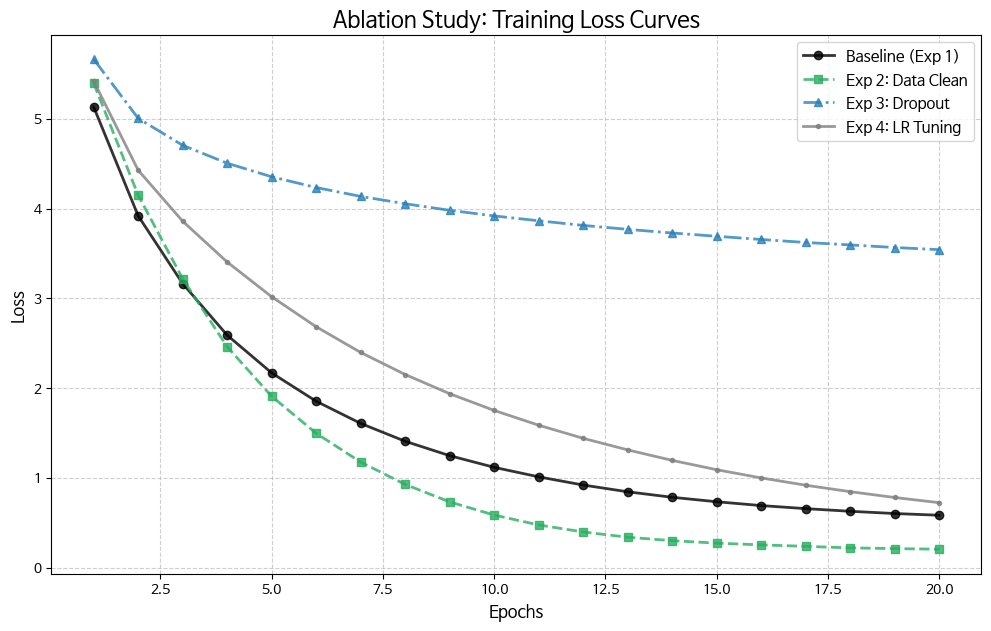

In [107]:
import matplotlib.pyplot as plt

def plot_combined_loss_curves(loss_dict):
    plt.figure(figsize=(12, 7))
    
    # 각 실험별 선 스타일과 마커 설정
    styles = {
        'Baseline (Exp 1)': {'color': 'black', 'linestyle': '-', 'marker': 'o'},
        'Exp 2: Data Clean': {'color': '#27ae60', 'linestyle': '--', 'marker': 's'},
        'Exp 3: Dropout': {'color': '#2980b9', 'linestyle': '-.', 'marker': '^'},
        'Exp 5: LR Tuning': {'color': '#e74c3c', 'linestyle': ':', 'marker': 'd'}
    }
    
    for name, losses in loss_dict.items():
        epochs = range(1, len(losses) + 1)
        
        # 딕셔너리에 정의된 스타일 가져오기 (없으면 기본값)
        style = styles.get(name, {'color': 'gray', 'linestyle': '-', 'marker': '.'})
        
        plt.plot(epochs, losses, label=name, 
                 color=style['color'], linestyle=style['linestyle'], 
                 marker=style['marker'], alpha=0.8, linewidth=2)
    
    # 그래프 제목 및 축 라벨 설정
    plt.title('Ablation Study: Training Loss Curves', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # 범례 및 그리드 추가
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()

# LR curve 시각화
all_experiment_losses = {
    'Baseline (Exp 1)': train_losses_baseline,
    'Exp 2: Data Clean': train_losses_exp2,
    'Exp 3: Dropout': train_losses_exp3,
    'Exp 4: LR Tuning': train_losses_exp4
}
plot_combined_loss_curves(all_experiment_losses)

In [115]:
def greedy_decode_with_attention(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    tok_sent = preprocess_sentence(sentence, s_type="ko")
    
    src_ids = kor_tokenizer.encode(tok_sent)
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    pred_indices = outputs.argmax(2).squeeze(1).tolist()
    
    if 2 in pred_indices: 
        pred_indices = pred_indices[:pred_indices.index(2)]
        
    res_words = [eng_tokenizer.idx2word.get(idx, "<unk>") for idx in pred_indices if idx not in [0, 1]]

    attn_map = attentions.squeeze(1).cpu().numpy()
    attn_map = attn_map[:len(res_words), :len(tok_sent)]

    return res_words, tok_sent, attn_map


=================================== [문장 1] 오바마는 대통령이다. ===================================
[1. Baseline (Greedy)] 번역: president obama has been the president .
[1-1. Best Epoch (Qualitative)] 번역: obama is the president .
[2. Data Cleaning (Data Effect)] 번역: obama was responding to the president .
[3. Dropout (Reg. Effect)] 번역: obama is also a close .
[4. LR Tuning (Opt. Effect)] 번역: obama s inauguration .
[5. Beam Search (Search Effect)] 번역: president obama has been the president .


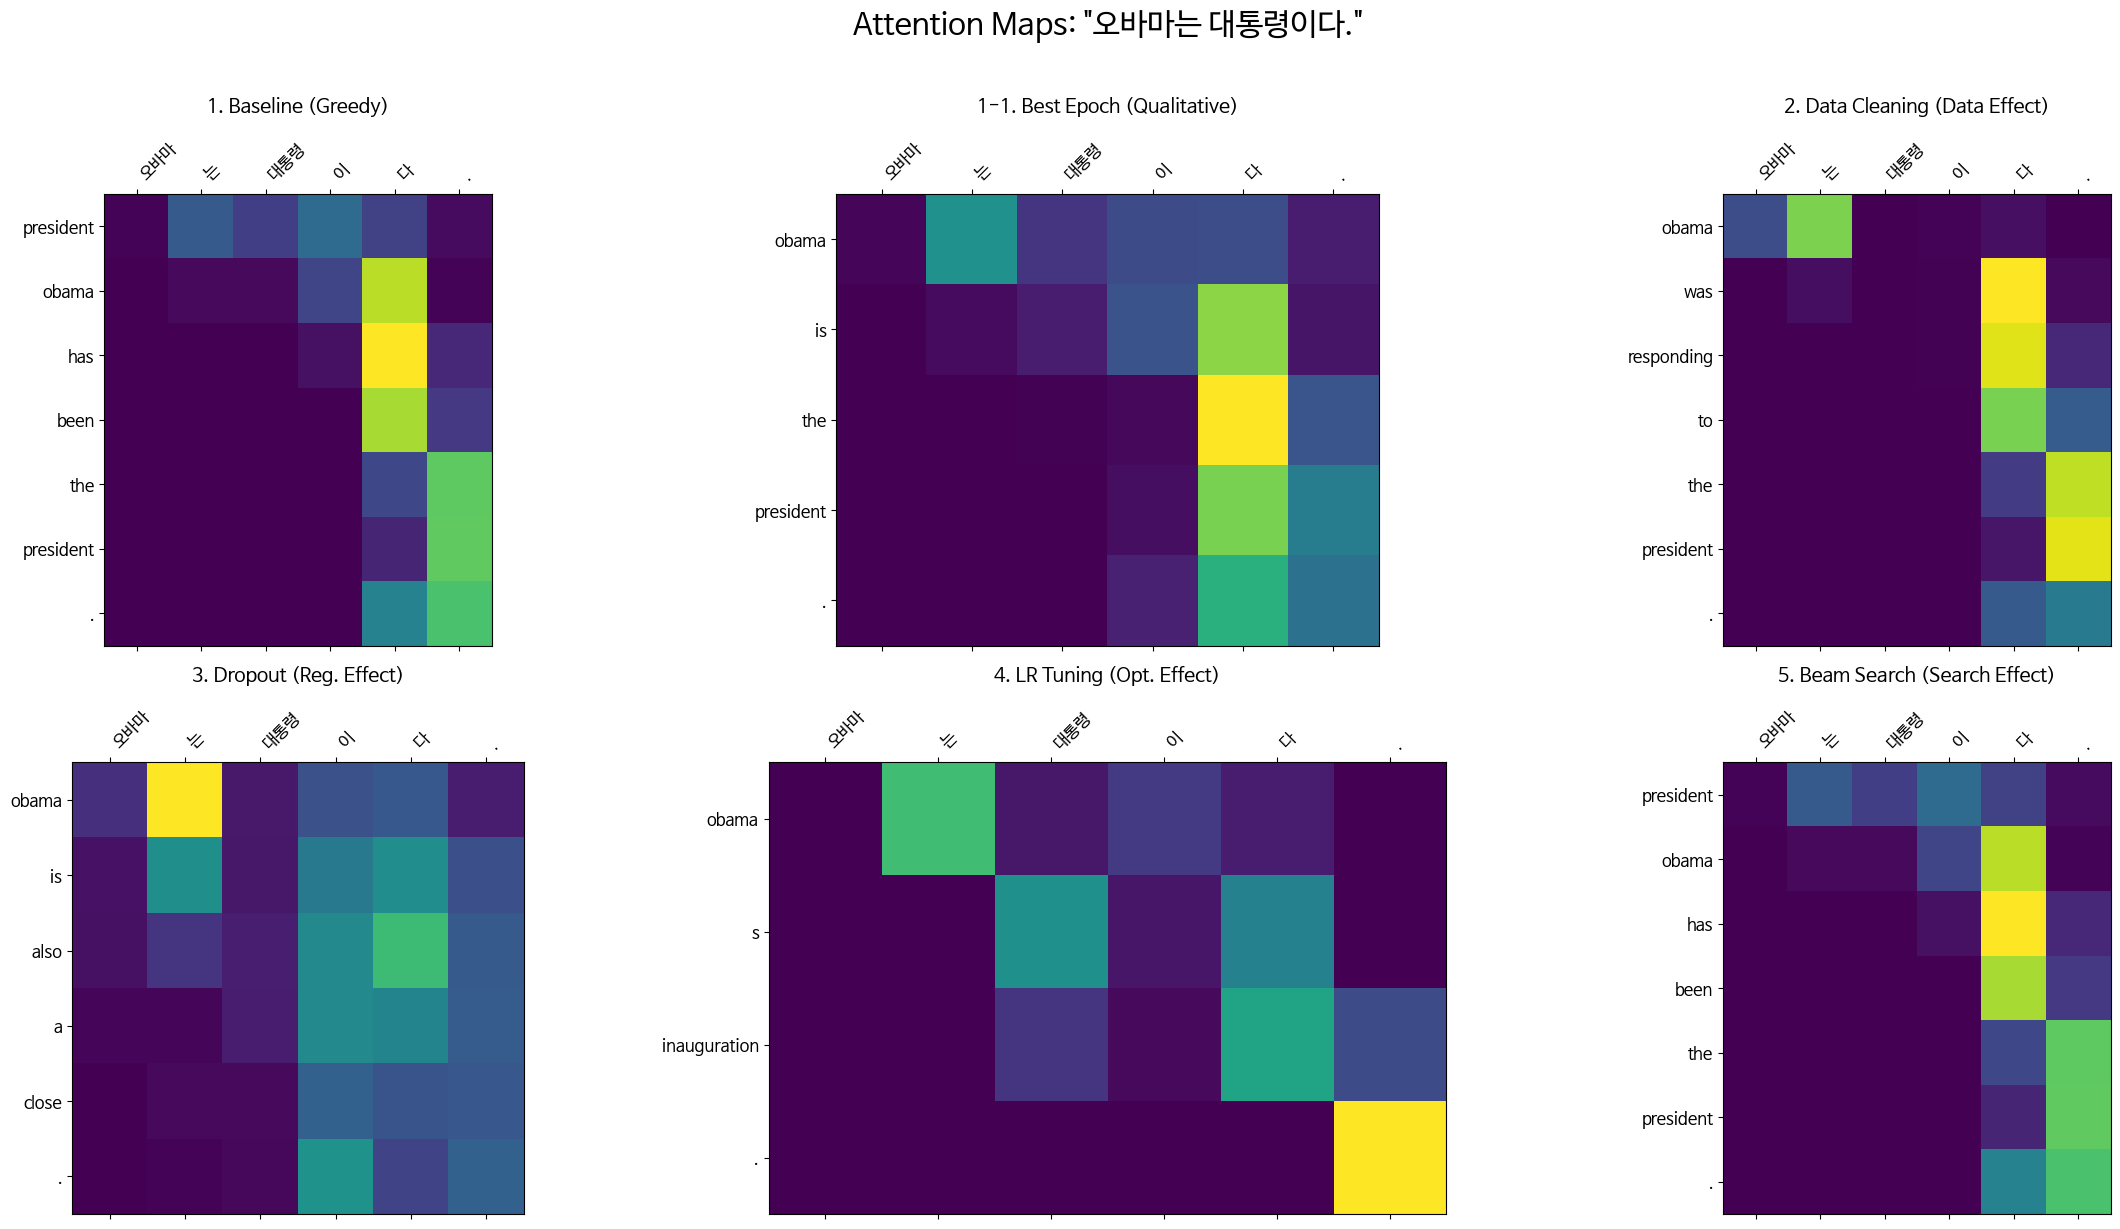


=================================== [문장 2] 시민들은 도시 속에 산다. ===================================
[1. Baseline (Greedy)] 번역: citizens of <unk> died from city city .
[1-1. Best Epoch (Qualitative)] 번역: citizens of cities , the city s sacred cities was taken off the city of <unk> .
[2. Data Cleaning (Data Effect)] 번역: ex the <unk>
[3. Dropout (Reg. Effect)] 번역: citizens are in cities , cities .
[4. LR Tuning (Opt. Effect)] 번역: i think it will go up in cities , even though it s like , there s a city .
[5. Beam Search (Search Effect)] 번역: citizens taken back to the streets in towns city .


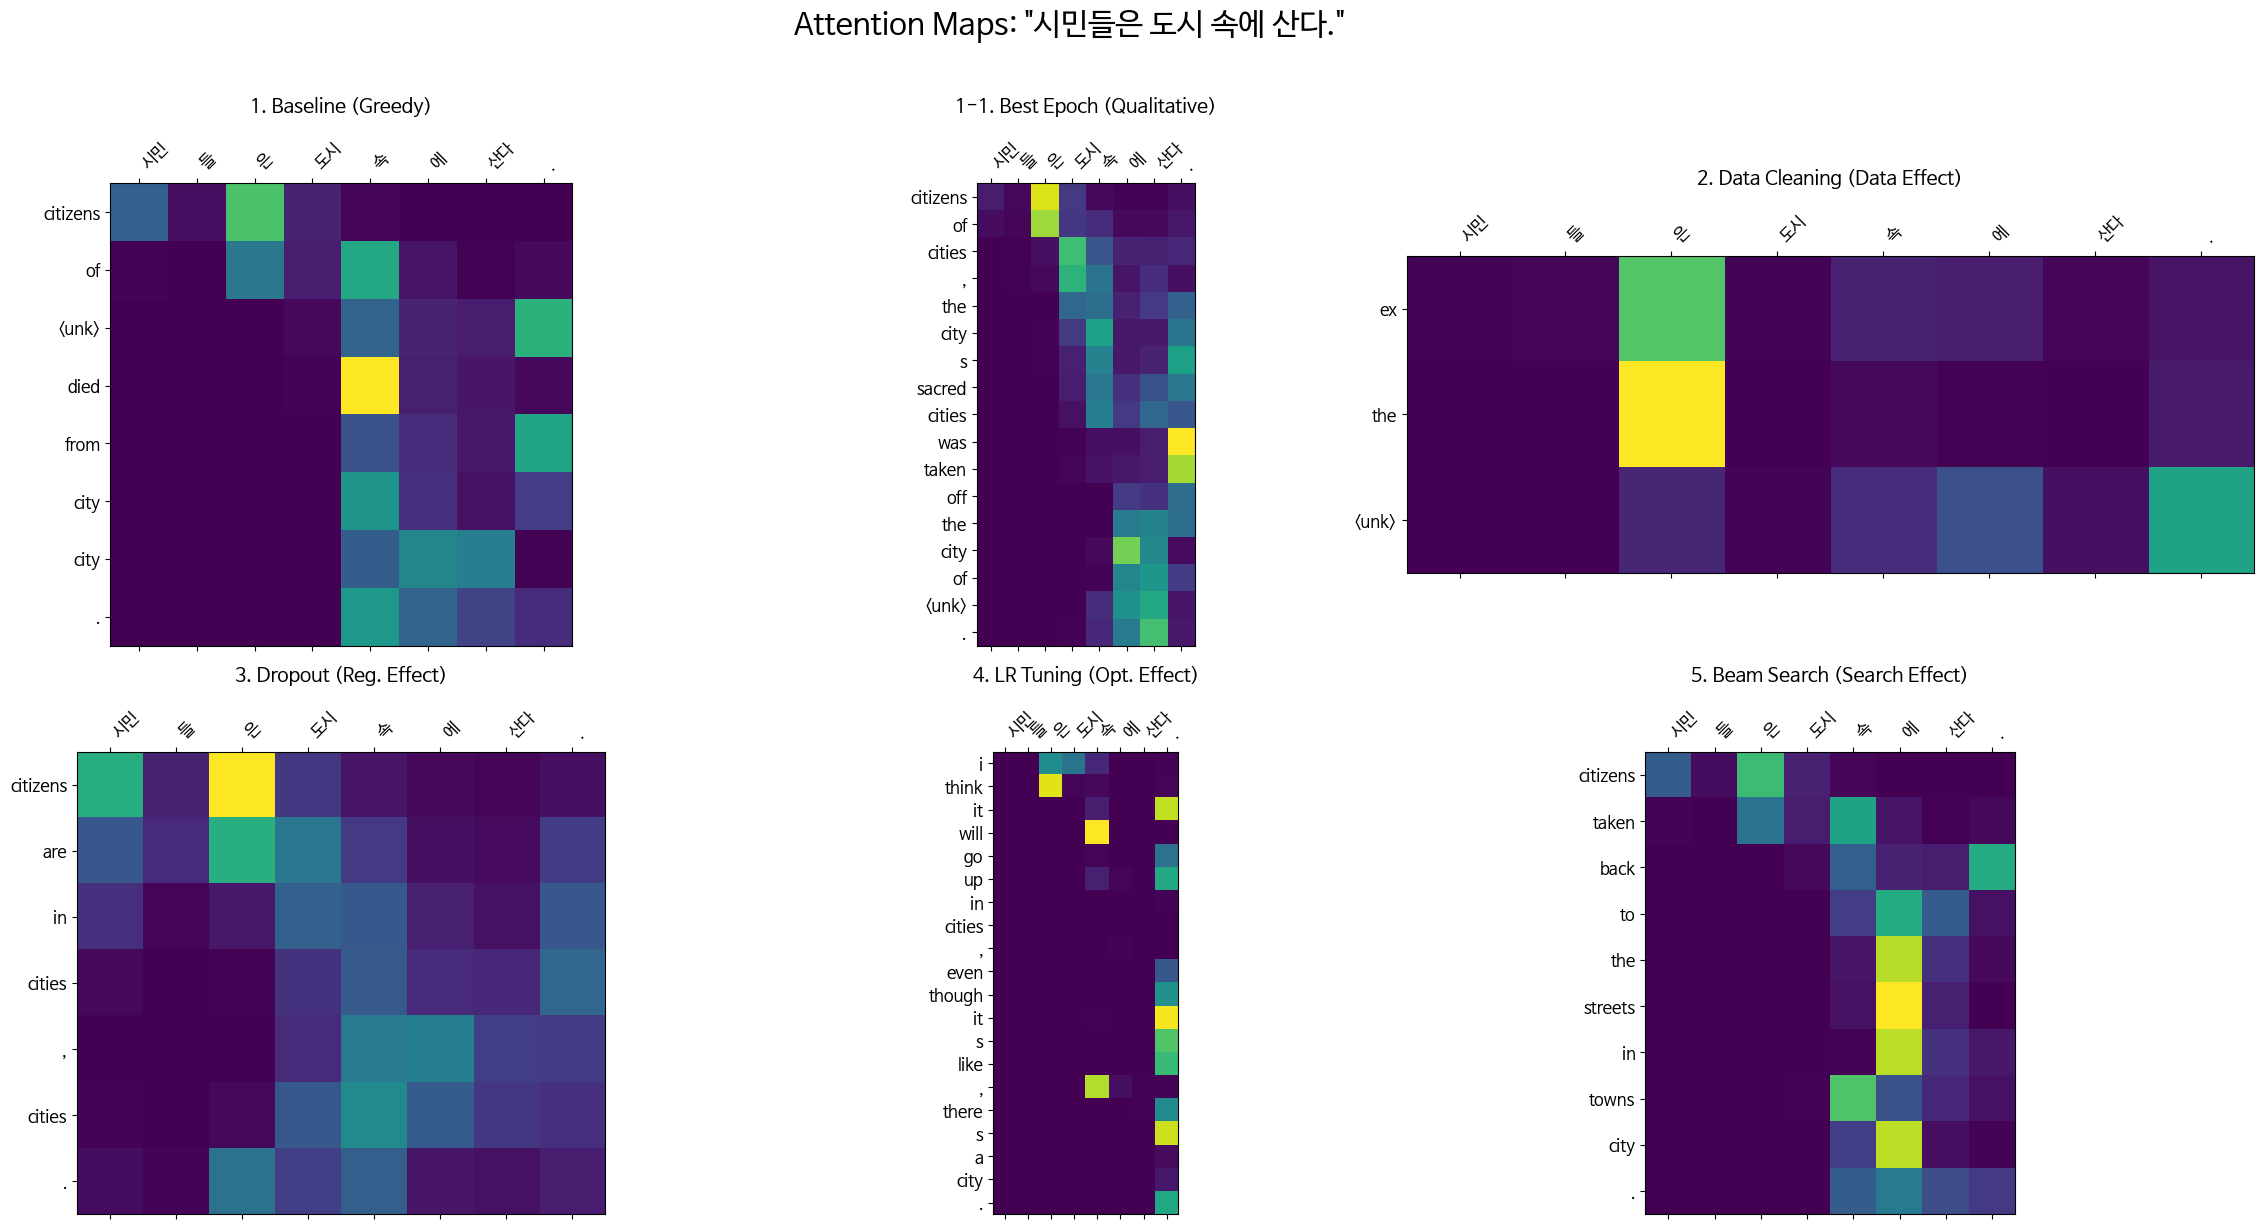


=================================== [문장 3] 커피는 필요 없다. ===================================
[1. Baseline (Greedy)] 번역: coffee has not need any change .
[1-1. Best Epoch (Qualitative)] 번역: coffee is not necessary .
[2. Data Cleaning (Data Effect)] 번역: coffee is no easy , <unk> for anything , but it s not anything .
[3. Dropout (Reg. Effect)] 번역: coffee coffee need to need to do .
[4. LR Tuning (Opt. Effect)] 번역: coffee is available in the right direction .
[5. Beam Search (Search Effect)] 번역: coffee has not need any change .


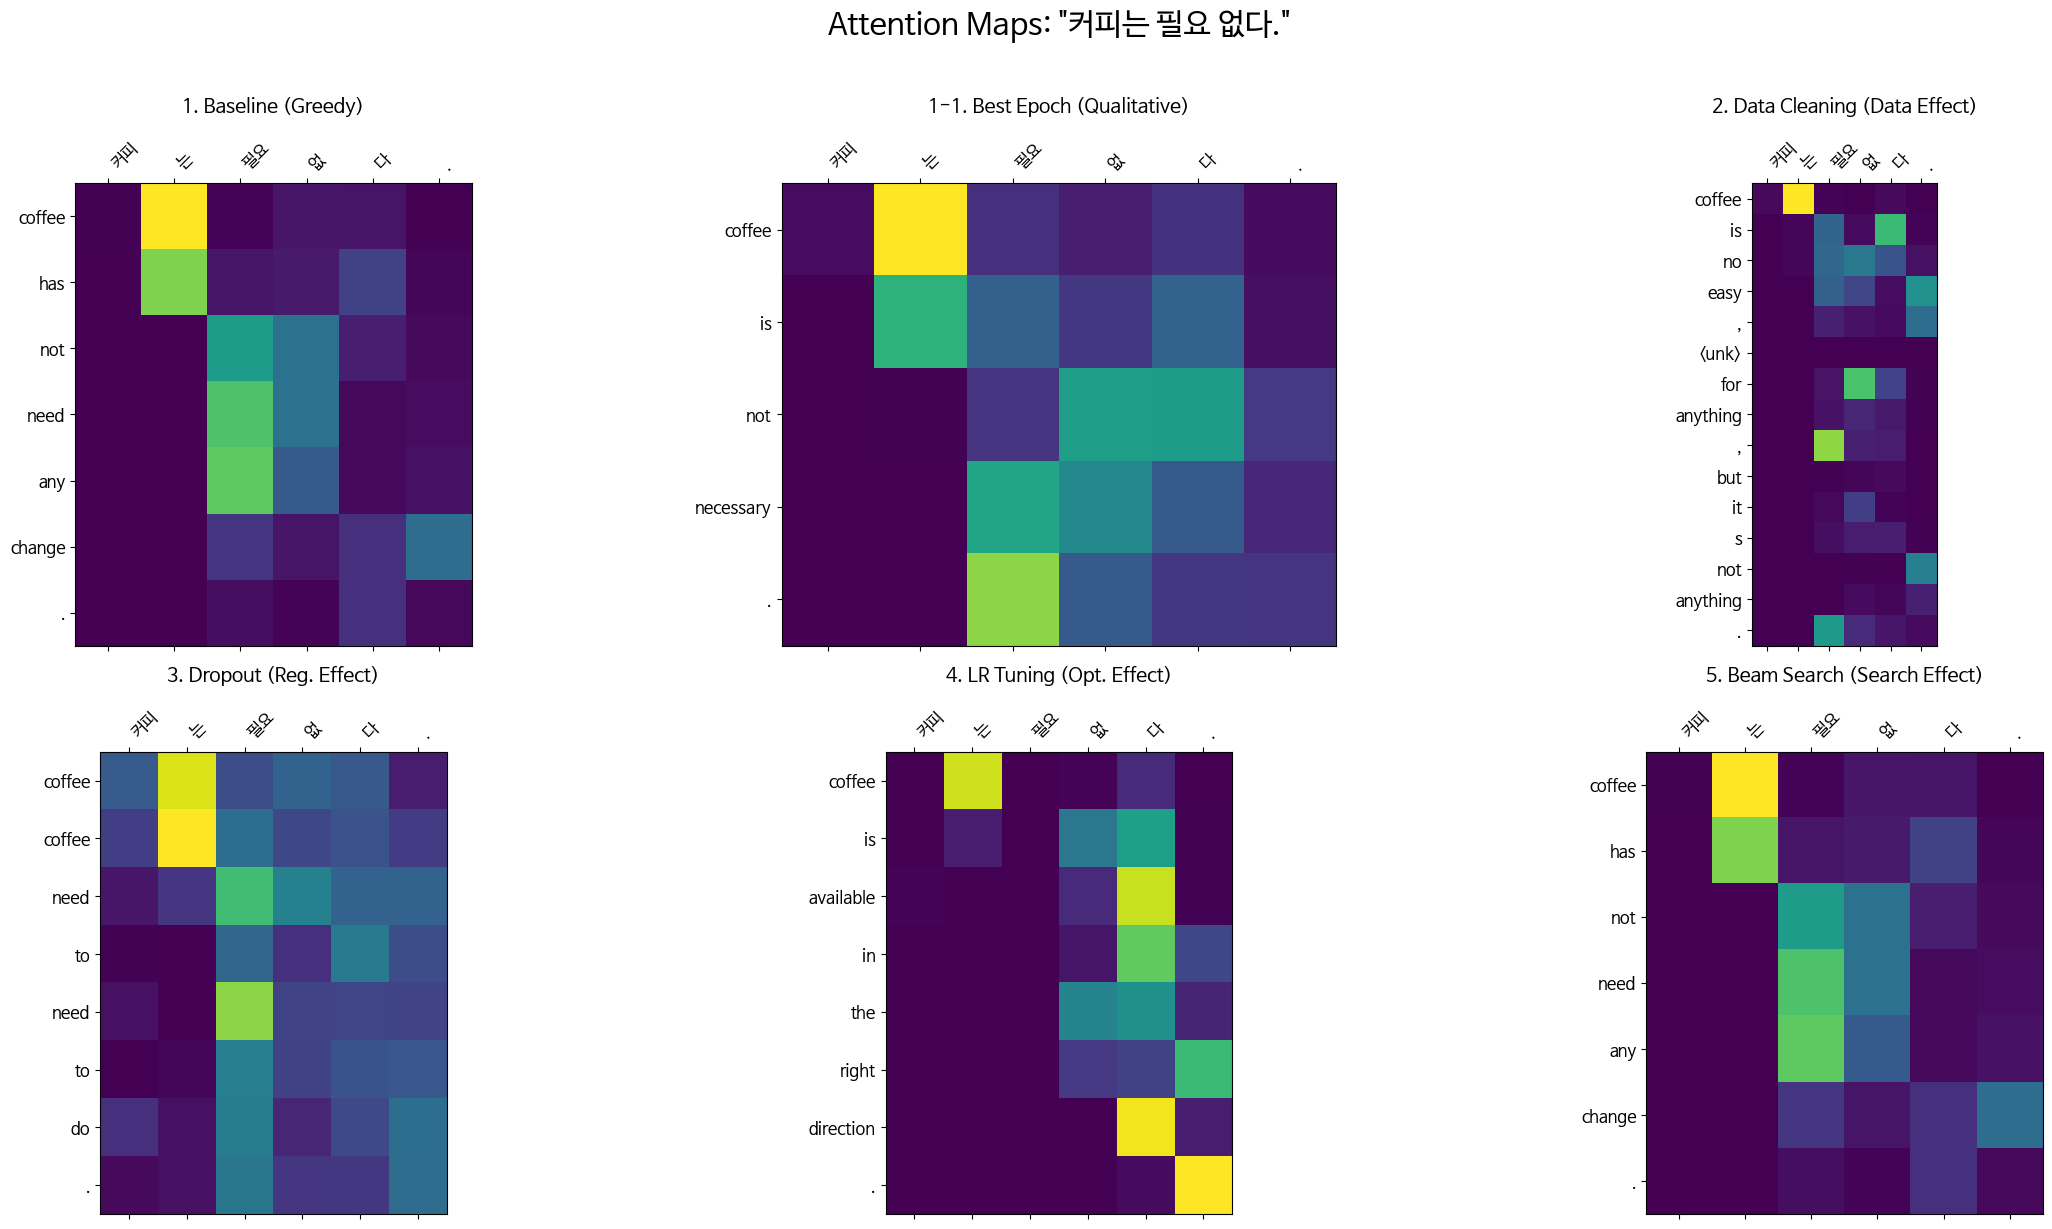


=================================== [문장 4] 일곱 명의 사망자가 발생했다. ===================================
[1. Baseline (Greedy)] 번역: seven people were killed .
[1-1. Best Epoch (Qualitative)] 번역: seven deaths were killed .
[2. Data Cleaning (Data Effect)] 번역: one death was not hurt .
[3. Dropout (Reg. Effect)] 번역: the death toll from the quake was killed .
[4. LR Tuning (Opt. Effect)] 번역: two were dead , an area was killed .
[5. Beam Search (Search Effect)] 번역: seven people were killed .


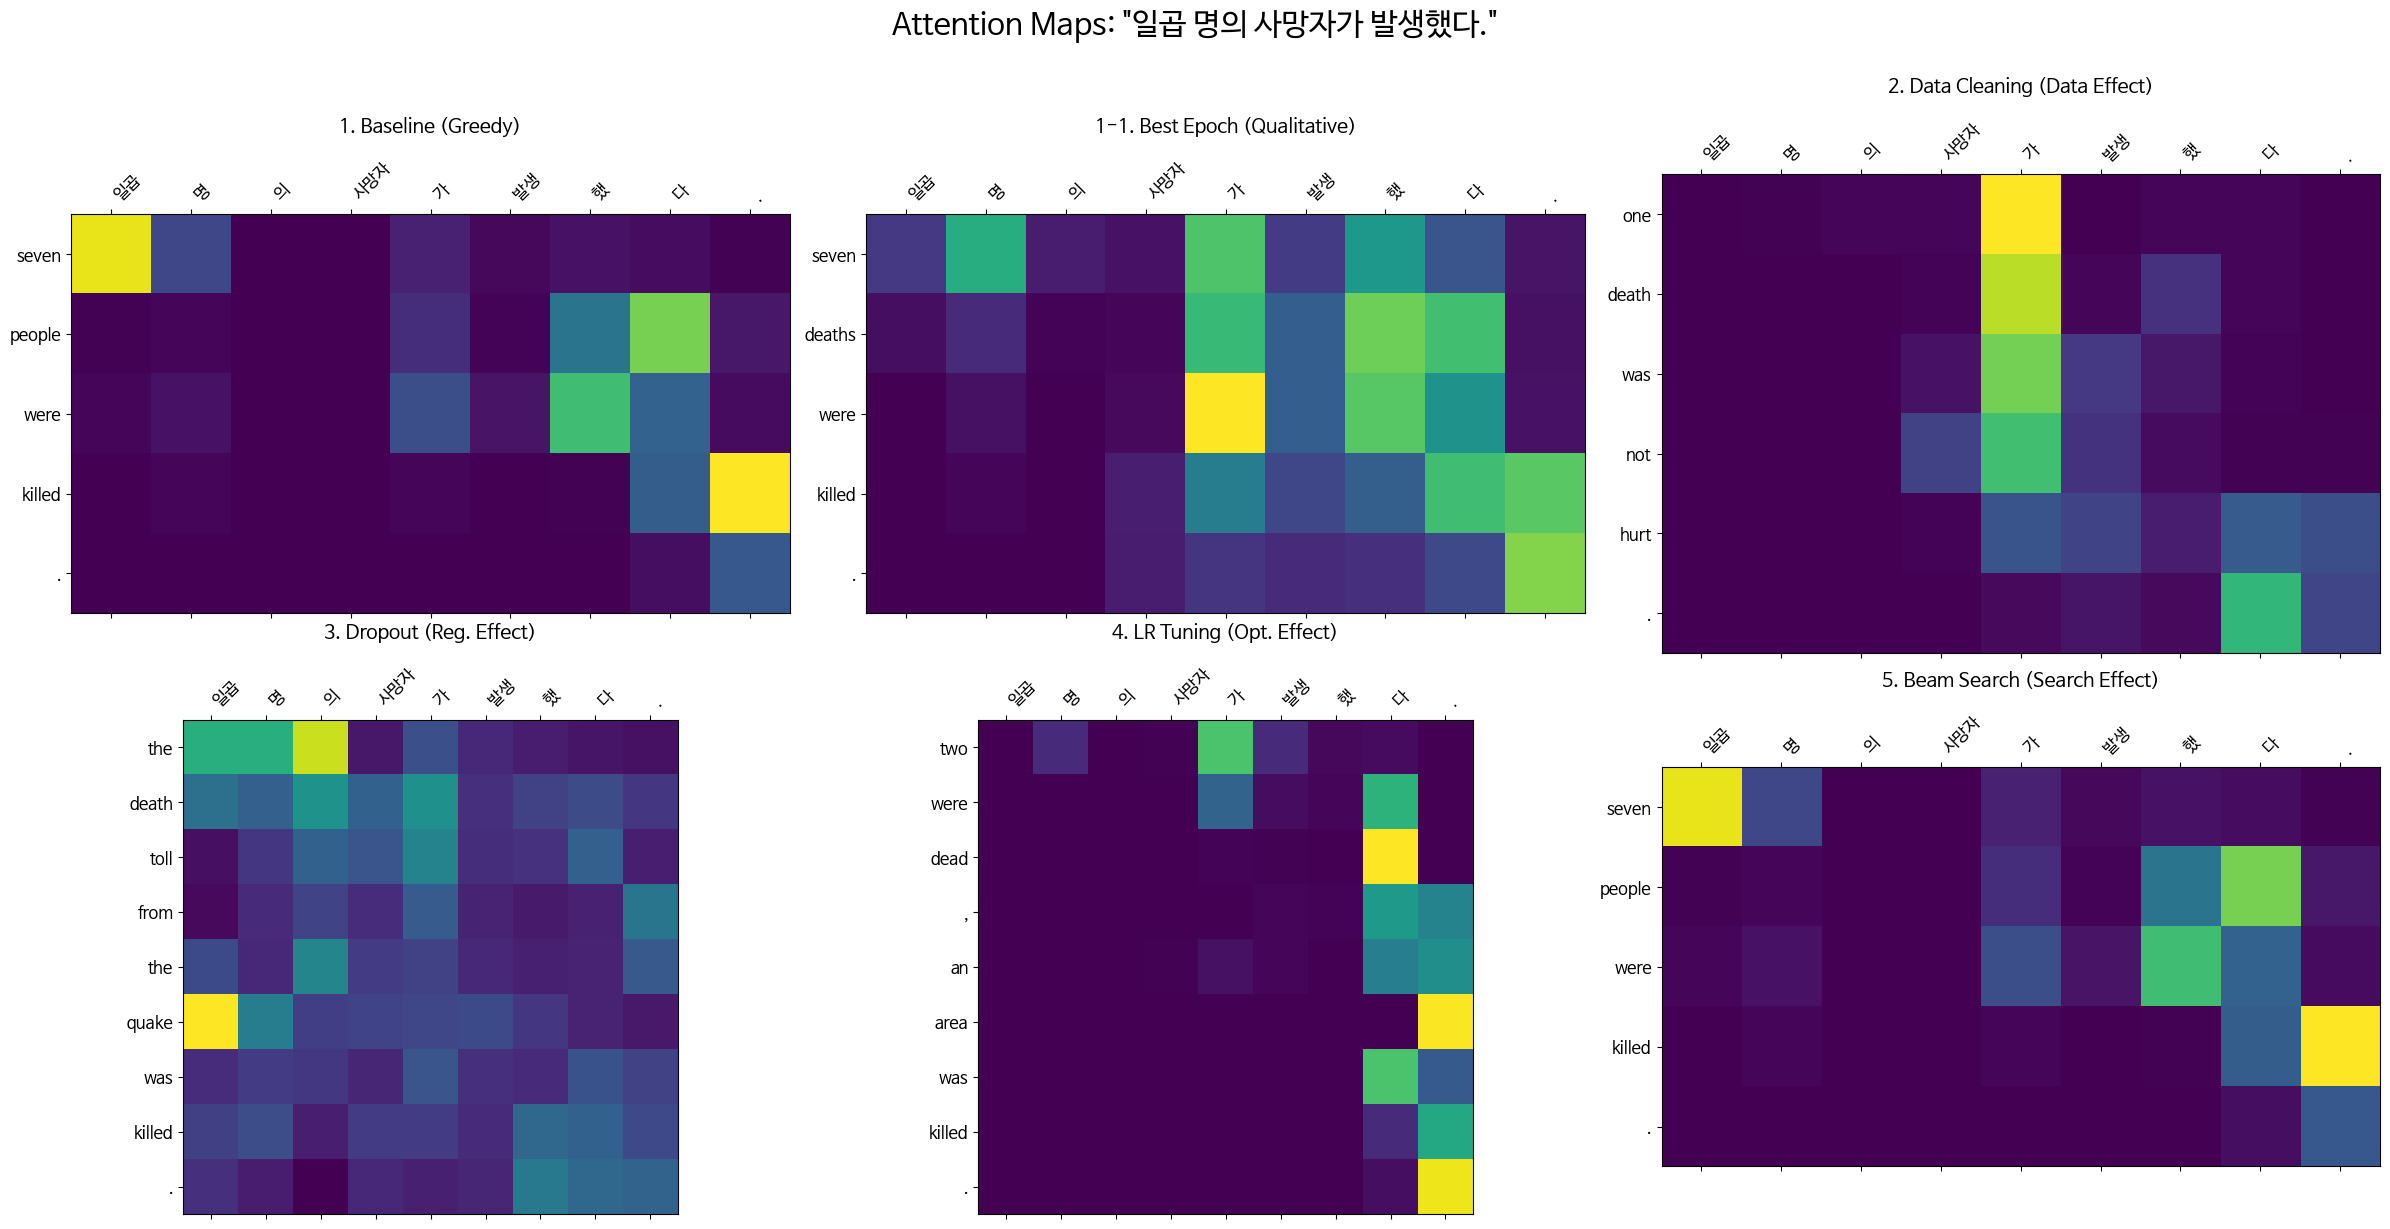


=================================== [문장 5] 정부는 새로운 정책을 발표했다. ===================================
[1. Baseline (Greedy)] 번역: the government has announced policy of new policy on government policy .
[1-1. Best Epoch (Qualitative)] 번역: the government has announced a policy of new policy policy toward the new policy initiative .
[2. Data Cleaning (Data Effect)] 번역: the government would then policy on a new policy .
[3. Dropout (Reg. Effect)] 번역: the government announced plans to announce new policy policies .
[4. LR Tuning (Opt. Effect)] 번역: the government said new policies was a new policy .
[5. Beam Search (Search Effect)] 번역: the government has announced policy of new policy on government policy .


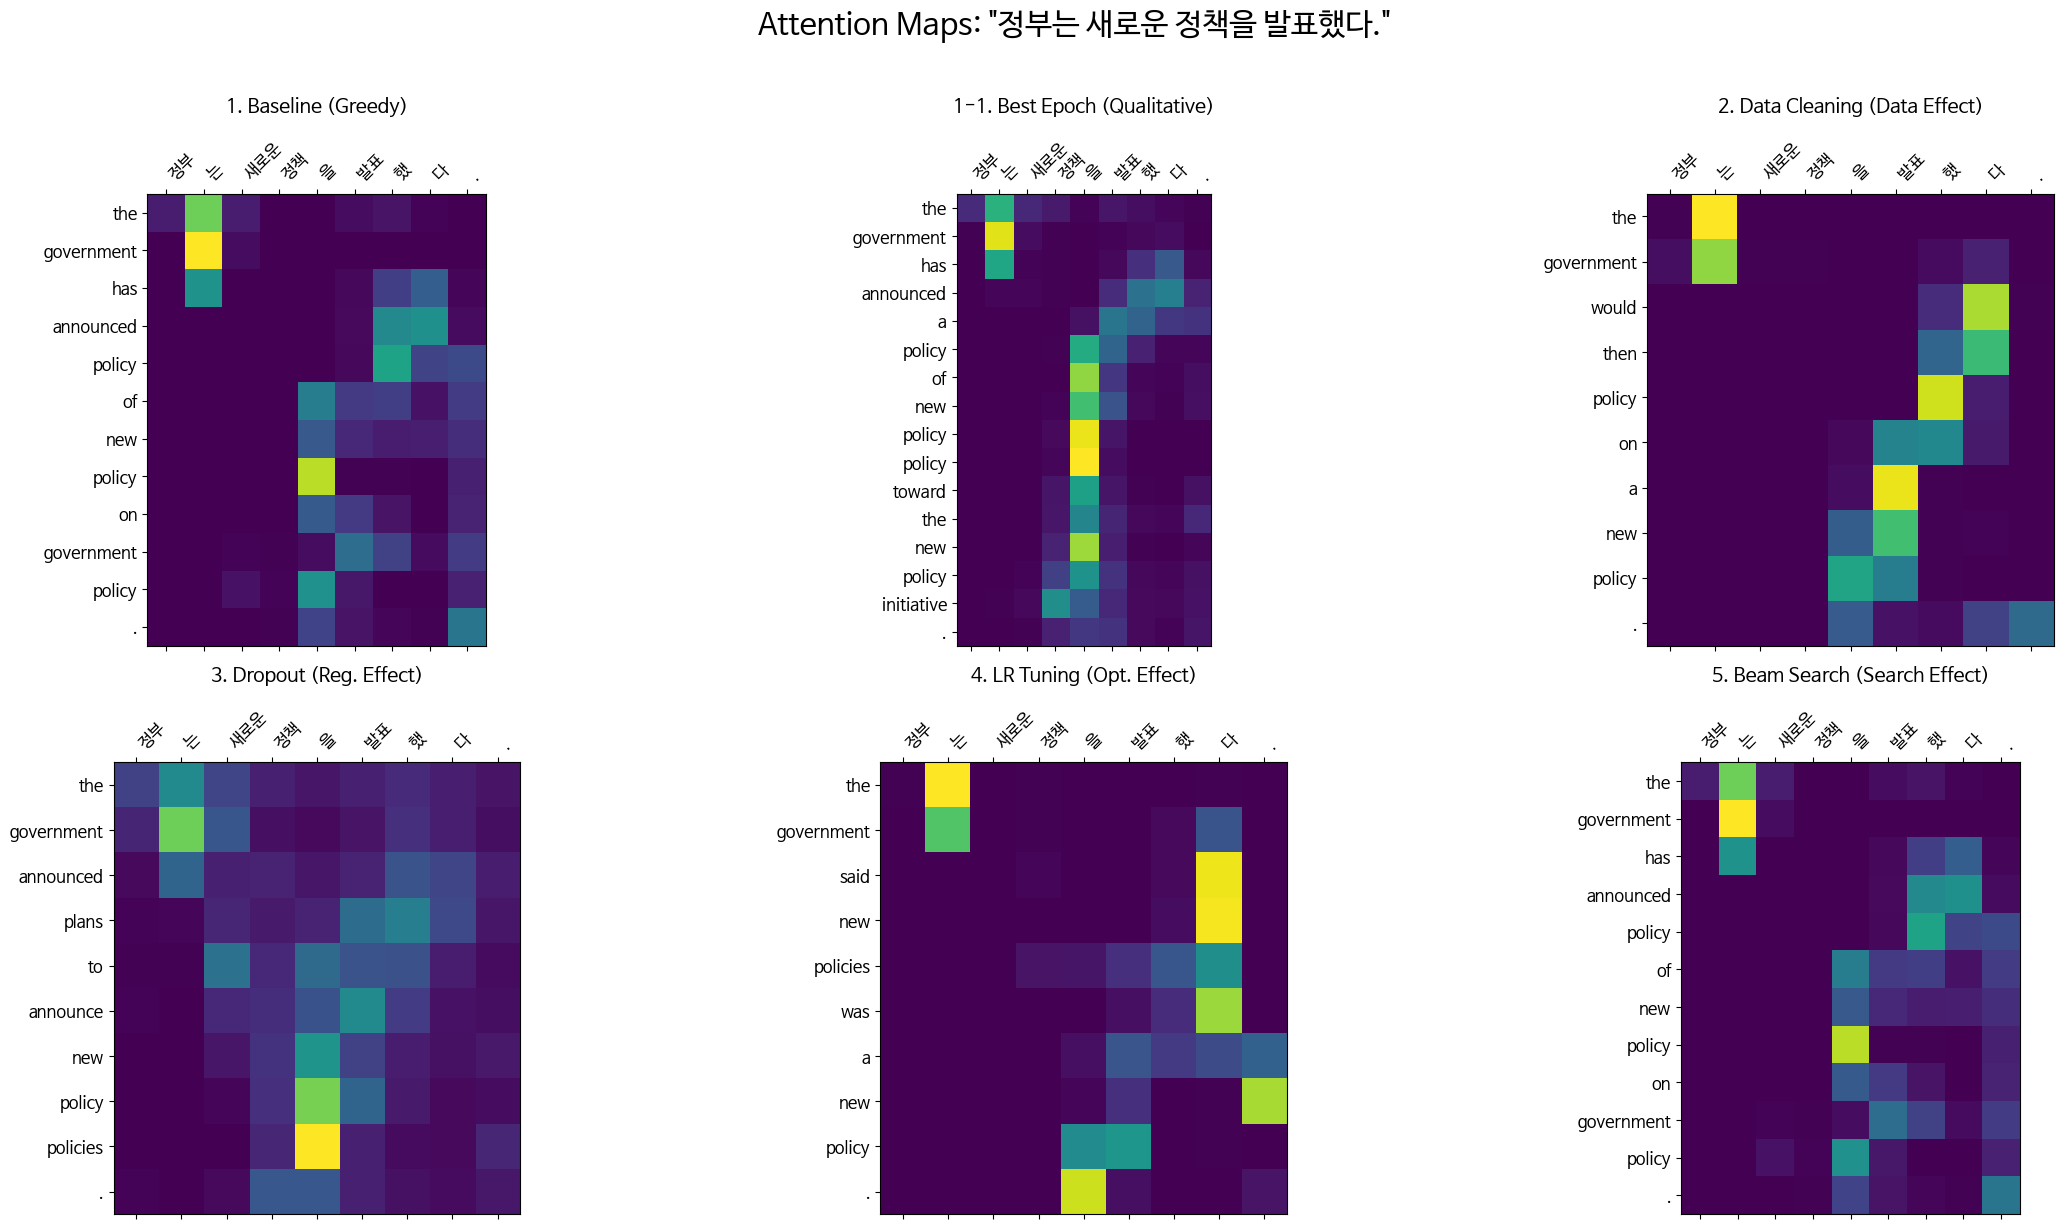


=================================== [문장 6] 경찰은 사건을 조사하고 있다. ===================================
[1. Baseline (Greedy)] 번역: police are investigating the case .
[1-1. Best Epoch (Qualitative)] 번역: police said they investigating the incident .
[2. Data Cleaning (Data Effect)] 번역: police are investigating the incident .
[3. Dropout (Reg. Effect)] 번역: police are investigating the incident .
[4. LR Tuning (Opt. Effect)] 번역: police are investigating the case . . .
[5. Beam Search (Search Effect)] 번역: police are investigating the case .


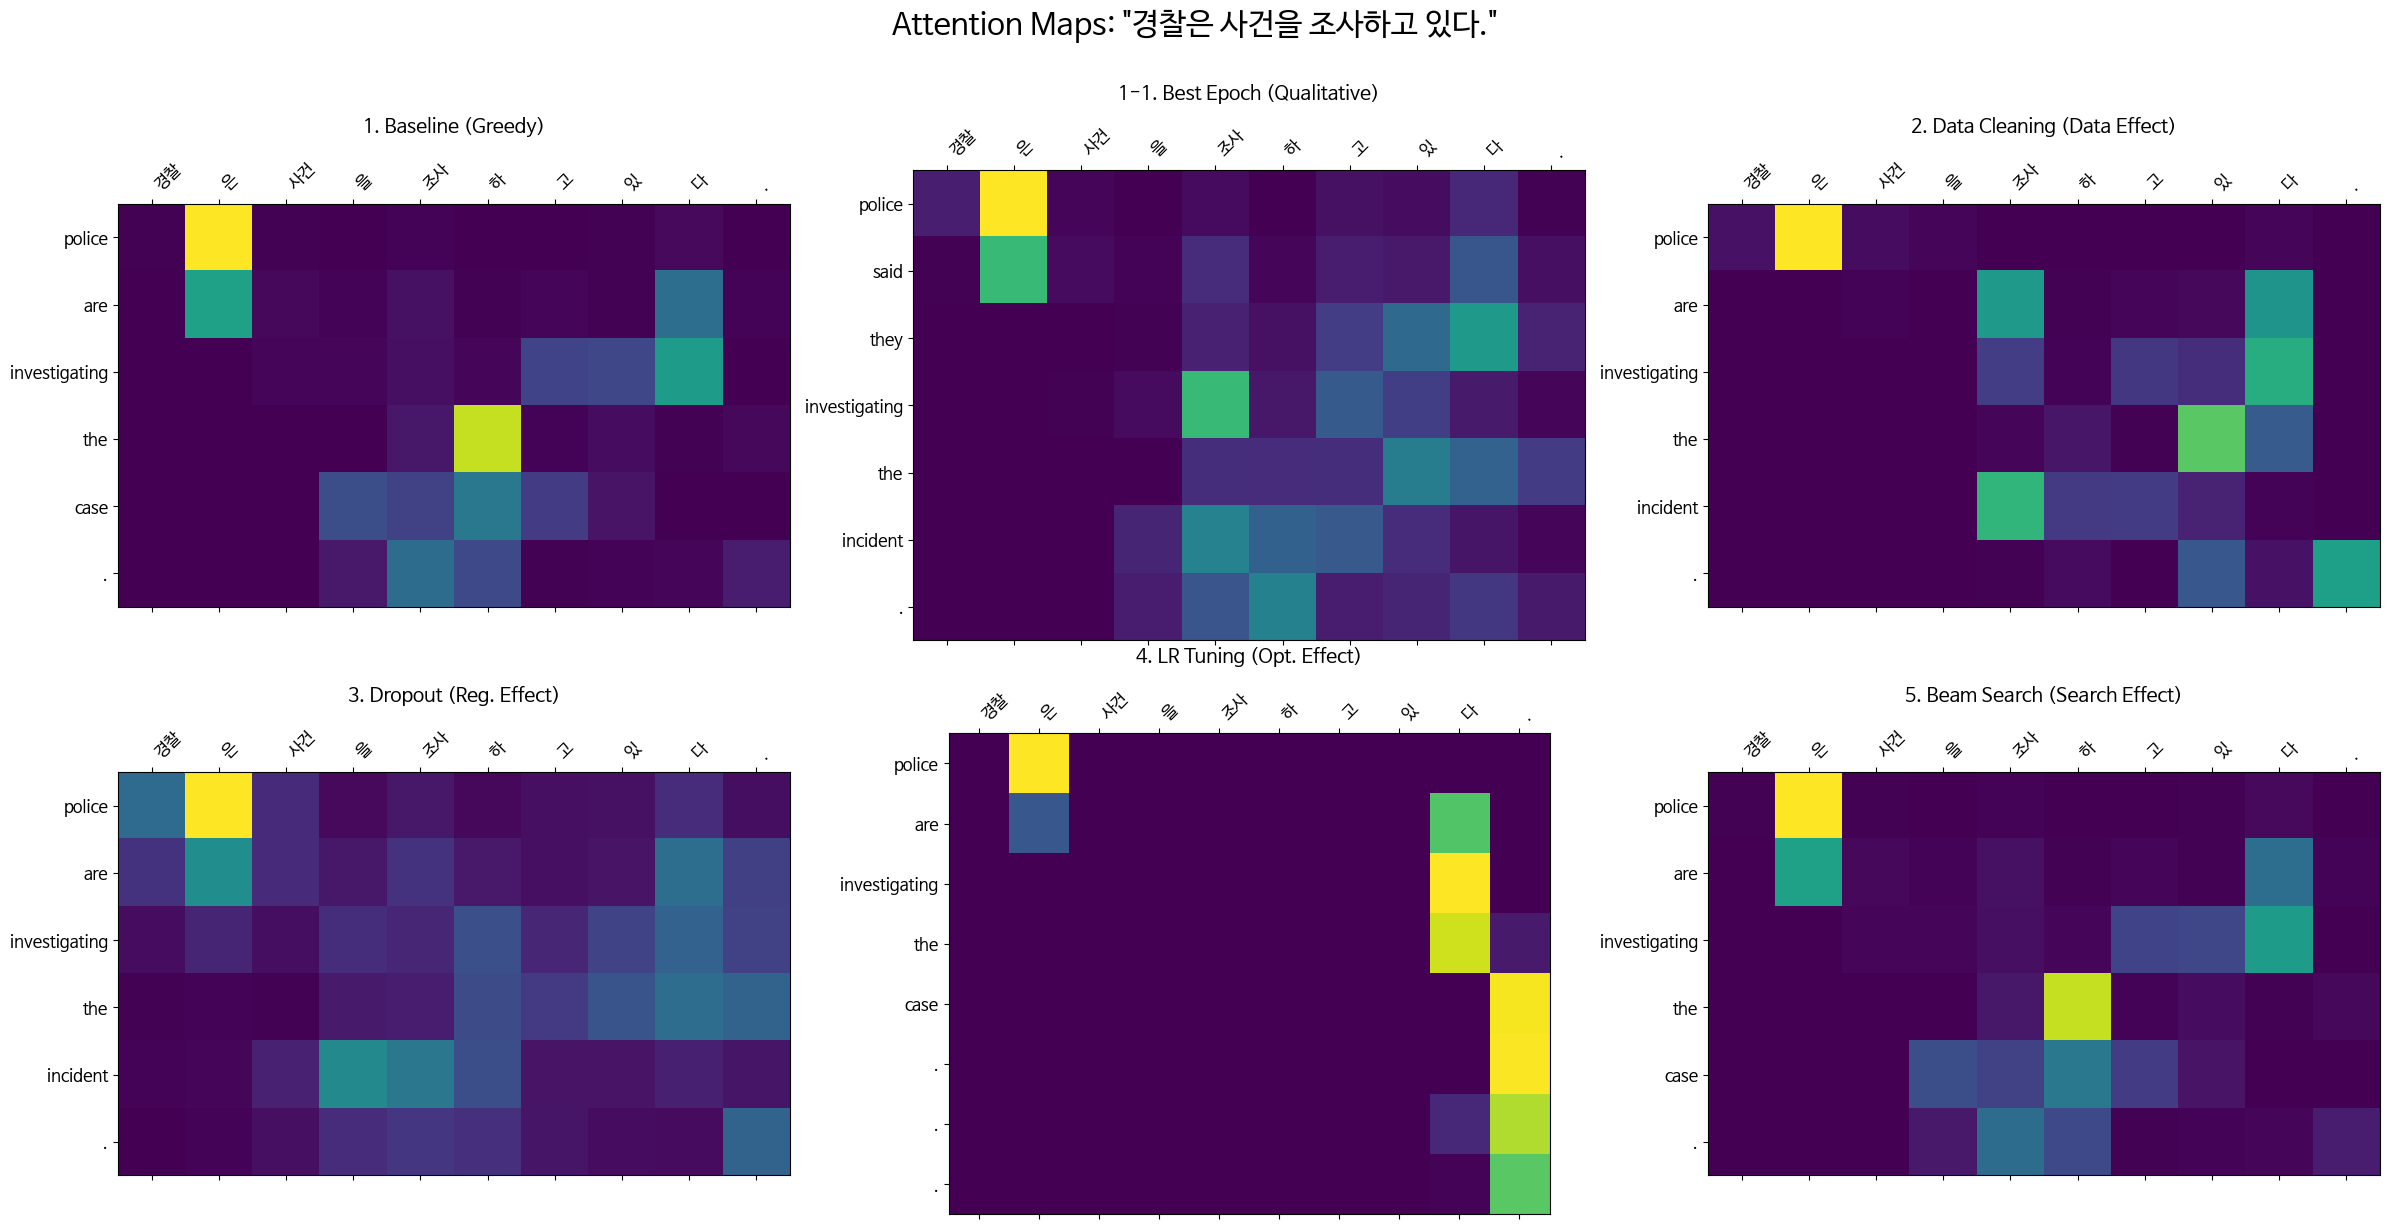


=================================== [문장 7] 시민들이 거리에 모였다. ===================================
[1. Baseline (Greedy)] 번역: citizens gathered to be <unk> .
[1-1. Best Epoch (Qualitative)] 번역: citizens of the streets of the streets .
[2. Data Cleaning (Data Effect)] 번역: public buildings in the street .
[3. Dropout (Reg. Effect)] 번역: citizens were gathered in streets streets .
[4. LR Tuning (Opt. Effect)] 번역: for example , he s .
[5. Beam Search (Search Effect)] 번역: citizens attended the streets .


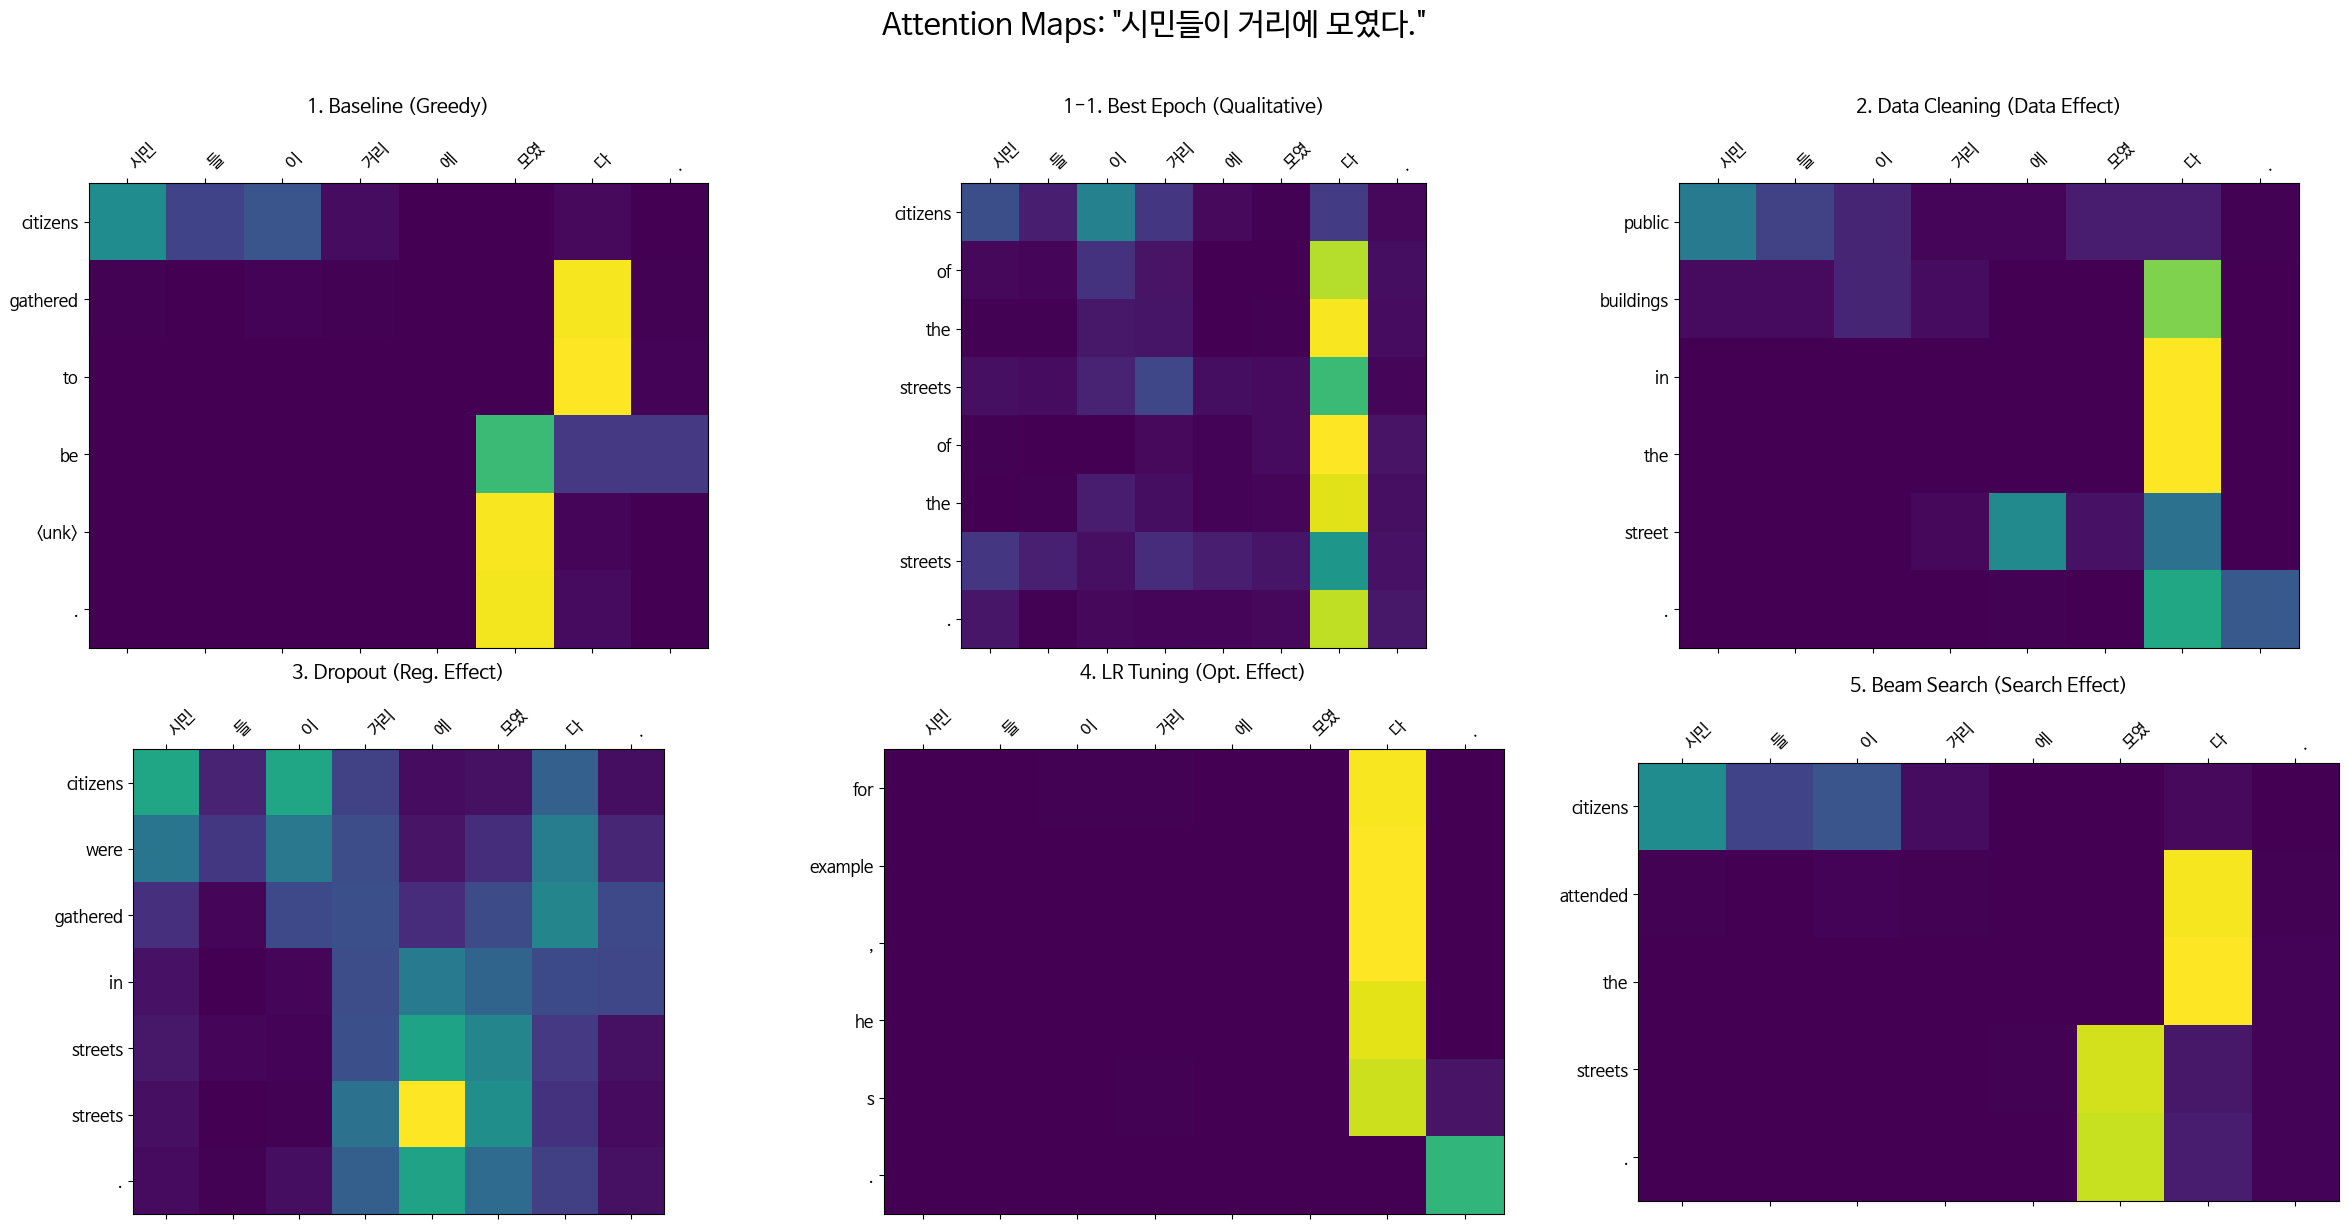

In [116]:
# 테스트 문장 통합 (루브릭 + 추가 실험)
final_test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "정부는 새로운 정책을 발표했다.",
    "경찰은 사건을 조사하고 있다.",
    "시민들이 거리에 모였다."
]

# 실험 설정 정의 (사용자님의 Ablation Study 번호에 맞춤)
experiment_configs = [
    {"name": "1. Baseline (Greedy)", "path": "model_epoch_20.pth", "method": "greedy"},
    {"name": "1-1. Best Epoch (Qualitative)", "path": "model_exp1_final.pth", "method": "greedy"}, 
    {"name": "2. Data Cleaning (Data Effect)", "path": "model_exp2_final.pth", "method": "greedy"},
    {"name": "3. Dropout (Reg. Effect)", "path": "model_exp3_final.pth", "method": "greedy"},
    {"name": "4. LR Tuning (Opt. Effect)", "path": "model_exp4_final.pth", "method": "greedy"},
    {"name": "5. Beam Search (Search Effect)", "path": "model_exp5_final.pth", "method": "beam"} # Baseline 모델 사용
]

# 루프 시작 전 전역 변수 확인
HID_DIM = 512 # 실험에서 사용한 hidden_dim

# 통합 테스트 실행
for s_idx, sentence in enumerate(final_test_sentences):
    print(f"\n{'='*35} [문장 {s_idx+1}] {sentence} {'='*35}")

    fig, axes = plt.subplots(2, 3, figsize=(24, 12)) 
    fig.suptitle(f'Attention Maps: "{sentence}"', fontsize=22, y=1.02)

    axes_flat = axes.flatten()
    
    for c_idx, config in enumerate(experiment_configs):
        # 1. 실험별 토크나이저 선택
        if "Data Cleaning" in config['name']:
            curr_kor_tok = kor_tokenizer_clean
            curr_eng_tok = eng_tokenizer_clean
        else:
            curr_kor_tok = kor_tokenizer_base
            curr_eng_tok = eng_tokenizer_base

        curr_input_dim = len(curr_kor_tok.word2idx)
        curr_output_dim = len(curr_eng_tok.word2idx)
        
        d_p = 0.5 if "Dropout" in config['name'] else 0.0
        
        # 2. 모델 초기화 및 가중치 로드
        attn_layer = BahdanauAttention(HID_DIM) 
        enc = Encoder(curr_input_dim, 256, HID_DIM, dropout_p=d_p)
        dec = Decoder(curr_output_dim, 256, HID_DIM, attention=attn_layer, dropout_p=d_p)
        model = Seq2SeqAttention(enc, dec, device).to(device)
        
        try:
            model.load_state_dict(torch.load(config['path'], map_location=device))
        except Exception as e:
            print(f"모델 로드 실패 ({config['path']}): {e}")
            continue

        model.eval() 
        
        # 3. 추론 및 어텐션 맵 데이터 추출
        with torch.no_grad():
            if config['method'] == "greedy":
                # 주의: 기존 greedy 추론 함수가 (번역된단어리스트, 입력토큰리스트, 어텐션맵)을 반환해야 합니다.
                res_words, tok_sent, attn_map = greedy_decode_with_attention(sentence, model, curr_kor_tok, curr_eng_tok)
            elif config['method'] == "beam":
                res_words, tok_sent, attn_map = beam_search_with_attention(model, sentence, curr_kor_tok, curr_eng_tok, beam_size=3)

        print(f"[{config['name']}] 번역: {' '.join(res_words)}")

        # 4. 각 칸(ax)에 히트맵 그리기
        ax = axes_flat[c_idx]
        cax = ax.matshow(attn_map, cmap='viridis')

        # 축 및 라벨 설정
        ax.set_xticks(range(len(tok_sent)))
        ax.set_xticklabels(tok_sent, rotation=45, ha='left', fontsize=12)
        ax.set_yticks(range(len(res_words)))
        ax.set_yticklabels(res_words, fontsize=12)
        
        ax.set_title(config['name'], pad=20, fontsize=14)

    # 레이아웃 겹치지 않게 정리 후 출력
    plt.tight_layout()
    plt.show()

### ablation study 결과 정리

#### 1. **Best 번역결과 찾기** 결과

>E1은 여러 epoch에서 안정적으로 올바른 번역이 생성되었다.  
특히 Epoch 4, 5, 8, 12, 14, 16에서  
“obama is the president”가 반복적으로 생성되었으며,  
정치 뉴스 도메인 표현에 대한 학습이 비교적 안정적으로 이루어진 것으로 보인다.

>반면 E2는 모든 epoch에서 불안정한 번역 결과가 나타났다.  
대부분의 결과에서 “city” 관련 표현은 유지되었으나,  
원문의 핵심 의미인 “산다(live)”가 제대로 반영되지 못하였다.  
그중 Epoch 10의 “citizens of the city"와 Epoch18의 "citizens, they re in good city."가 가장 자연스러운 결과에 가까웠다.

>E3는 일부 epoch(Epoch 3, 4, 15)에서  
“coffee is not necessary”와 같이 의미적으로 올바른 번역이 생성되었다.  
그러나 다른 epoch에서는 repetition 및 semantic drift 현상이 빈번하게 발생하였다.

>E4는 전반적으로 가장 안정적인 번역 성능을 보였다.  
특히 “seven deaths were reported”,  
“seven deaths were killed” 등의 뉴스체 표현이 반복적으로 생성되었으며,  
뉴스 도메인 데이터 편향의 영향이 나타난 것으로 보인다.

#### 2. lr curve

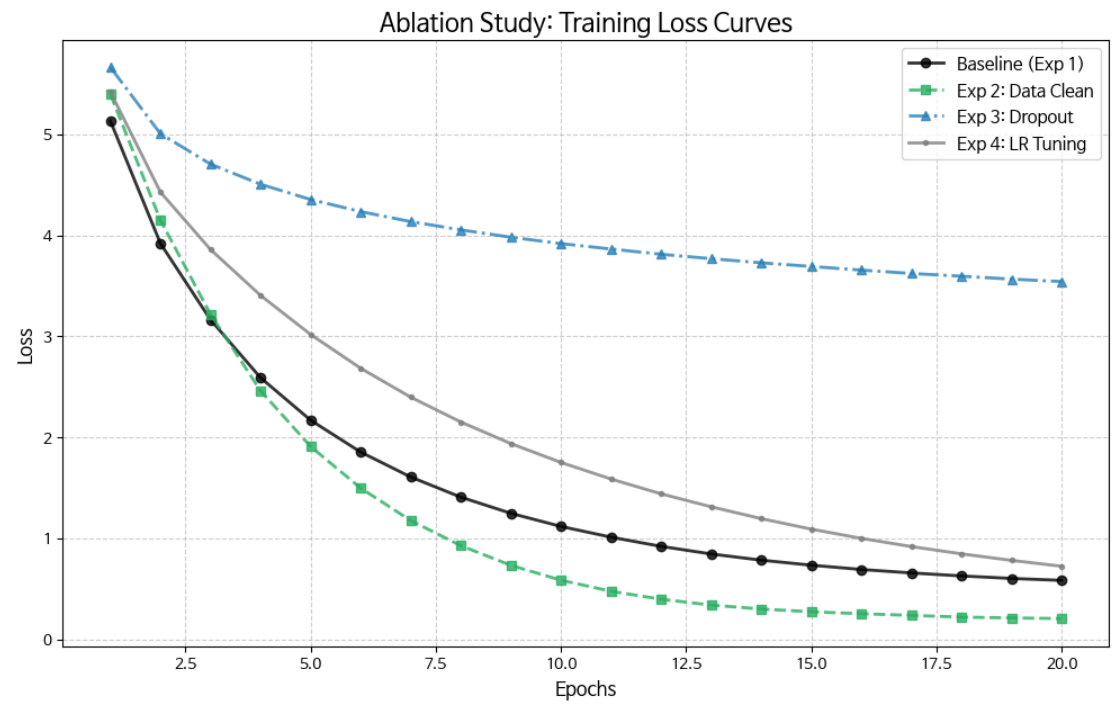

- **dropout 실험을 제외한 모든 실험은 최종적으로 loss 1.0 이하로 수렴하였고,**
- 그 중 가장 **빠르게 학습**을 한 것은 문장 길이를 30으로 제한했던 **데이터 정제 실험**이었다.
  - 아무래도 학습할 데이터가 더 간단해서 패턴 파악 및 학습에 도움이 되어 가장 빠르게 수렴한 것으로 보인다. 

#### 3. 테스트 문장 결과

|test 문장|baseline|best epoch|data cleaning|dropout|lr tuning|beam search|
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|오바마는 대통령이다.|president obama has been the president .|obama is the president .|obama was responding to the president .|obama is also a close .|obama s inauguration .|president obama has been the president .|
|시민들은 도시 속에 산다. |citizens of <unk> died from city city .|citizens of cities , the city s sacred cities was taken off the city of <unk> .|ex the <unk>|citizens are in cities , cities .|i think it will go up in cities , even though it s like , there s a city .|citizens taken back to the streets in towns city .|
|커피는 필요 없다.|coffee has not need any change .|coffee is not necessary .|coffee is no easy , <unk> for anything , but it s not anything .|coffee coffee need to need to do .|coffee is available in the right direction .|coffee has not need any change .|
|일곱 명의 사망자가 발생했다.|seven people were killed .|seven deaths were killed .|one death was not hurt .|the death toll from the quake was killed .|two were dead , an area was killed .|seven people were killed .|
|정부는 새로운 정책을 발표했다. |the government has announced policy of new policy on government policy .|the government has announced a policy of new policy policy toward the new policy initiative .|the government would then policy on a new policy .|the government announced plans to announce new policy policies .|the government said new policies was a new policy .|the government has announced policy of new policy on government policy .|
|경찰은 사건을 조사하고 있다.|police are investigating the case .|police said they investigating the incident .|police are investigating the incident .|police are investigating the incident .|police are investigating the case . . .|police are investigating the case .|
|시민들이 거리에 모였다.|citizens gathered to be <unk> .|citizens of the streets of the streets .|public buildings in the street .|citizens were gathered in streets streets .|for example , he s .|citizens attended the streets .|

- **greedy search방식이었던 baseline과 beam search 적용 모델의 경우 테스트 문장 중 2개를 제외하고는 동일한 번역결과를 출력하였다. beam search를 적용했을 때 더 좋은 결과를 기대했지만 큰 효과는 없었던 것으로 보임.**
- **'경찰은 사건을 조사하고 있다'라는 문장은 모든 모델에서 제대로 된 번역을 해냈다. 학습한 데이터셋이 뉴스 도메인인걸 생각했을 때 해당 문장이 뉴스에 많이 나올 주제라서 번역이 잘 된 것으로 보임.**  
**반면, '시민들은 도시 속에 산다'라는 문장은 모든 모델에서 제대로 번역해내지 못하였고, 그나마 dropout을 적용한 경우에 'citizens are in cities, cities.' 로 repition이 존재했지만 가장 의미가 근접했다.**
- **특정 실험이 최적의 결과 혹은 최악의 결과를 보였다고 말하기에는 애매한 부분이 있어 전체적인 평가를 하자면,**  
**각 실험에 대해 기대하던 효과보다는 단점이 부각되는 결과를 확인하였다.**  
  - dropout의 경우 최종 loss가 3.0에 이르는 수준인 점과 더불어 정성 평가를 하였을 때에도 더 학습이 필요했던 부분이 있었을 것 같고,
  - data cleaning의 경우 단순한 데이터를 학습하게 됨으로써 모델이 학습을 더 잘하는 것이 아니라 오히려 더 문장을 제대로 생성하지 못하는 모습이 관찰되었다.
- 또한, **전반적으로 여전히 모든 모델에서 repition과 hallucination 등의 현상이 관찰되었다.**

#### 4. attention map

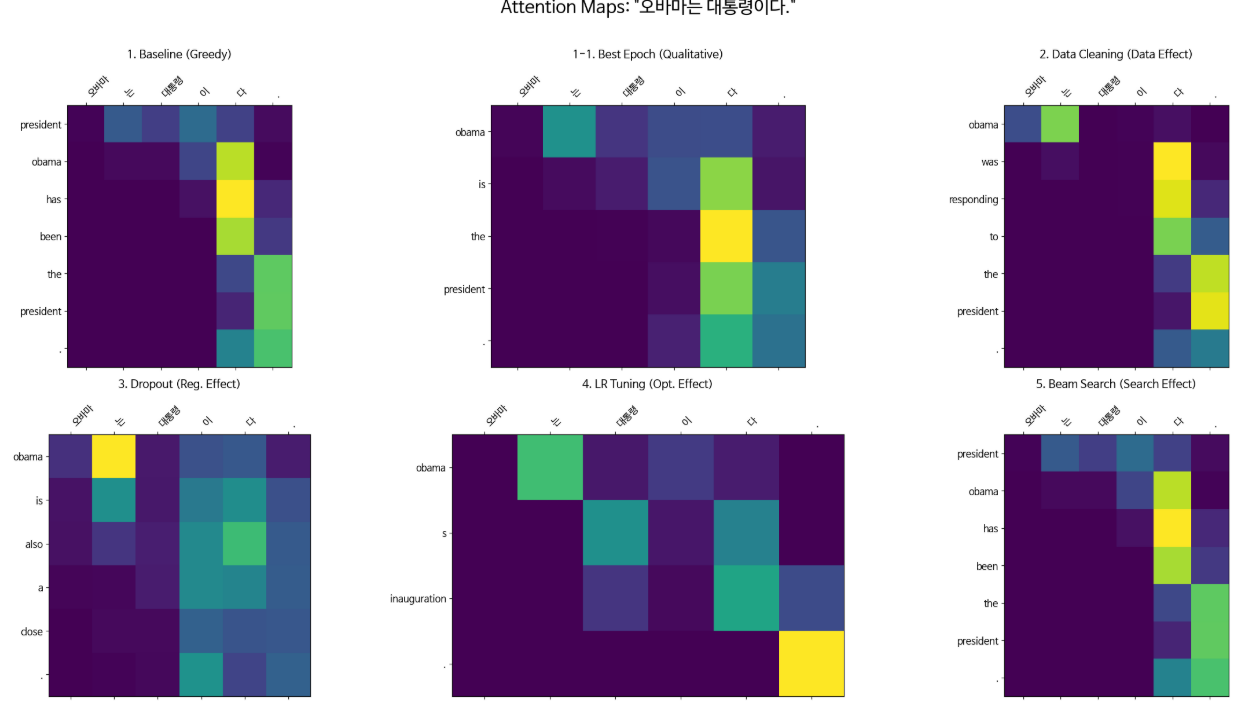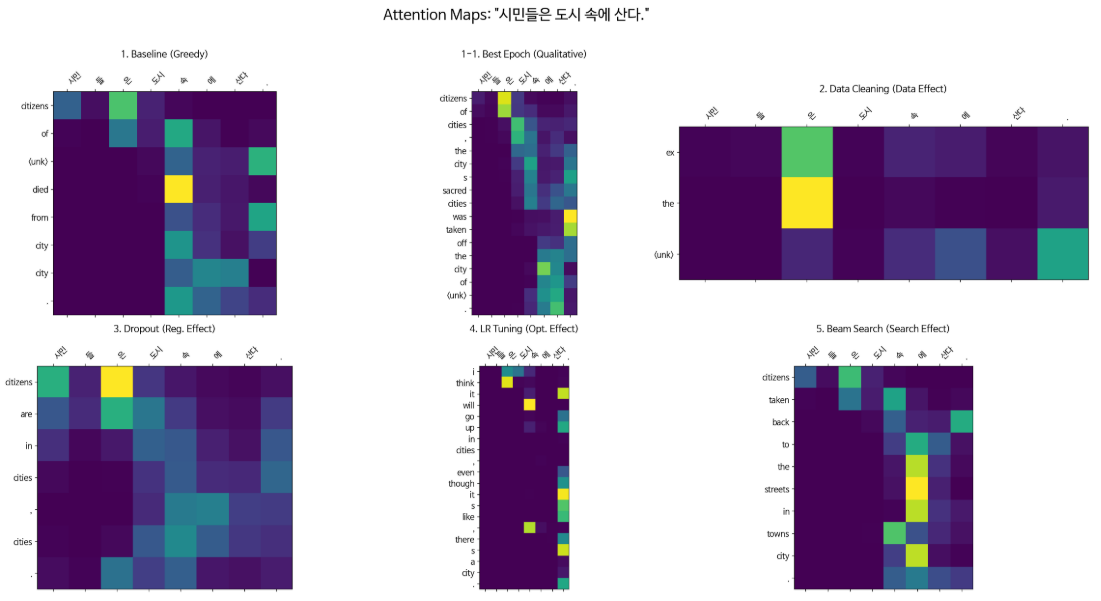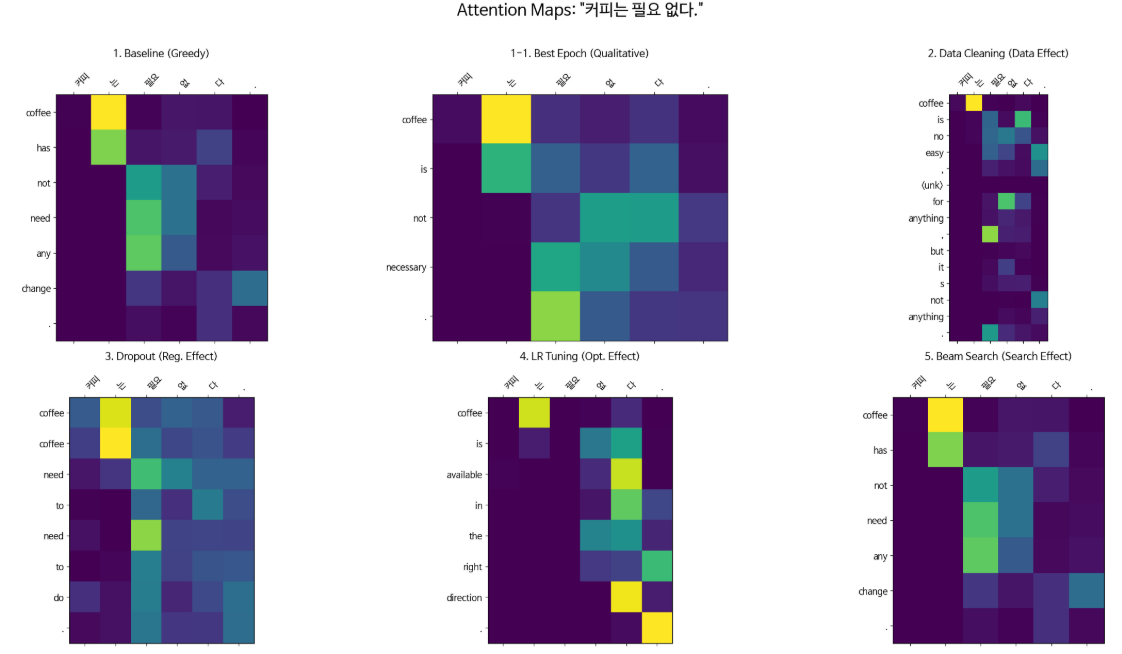
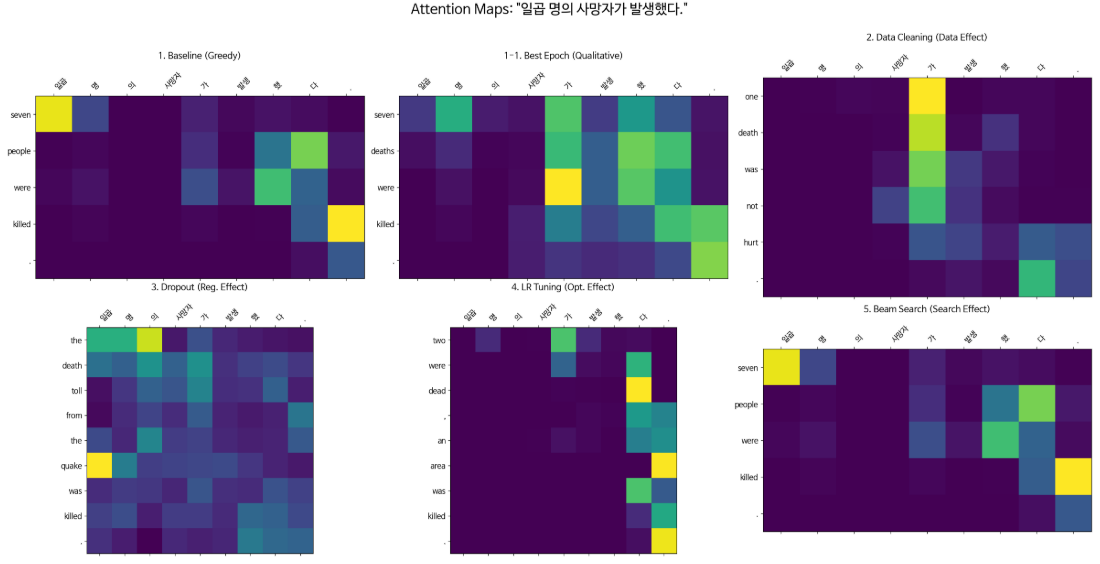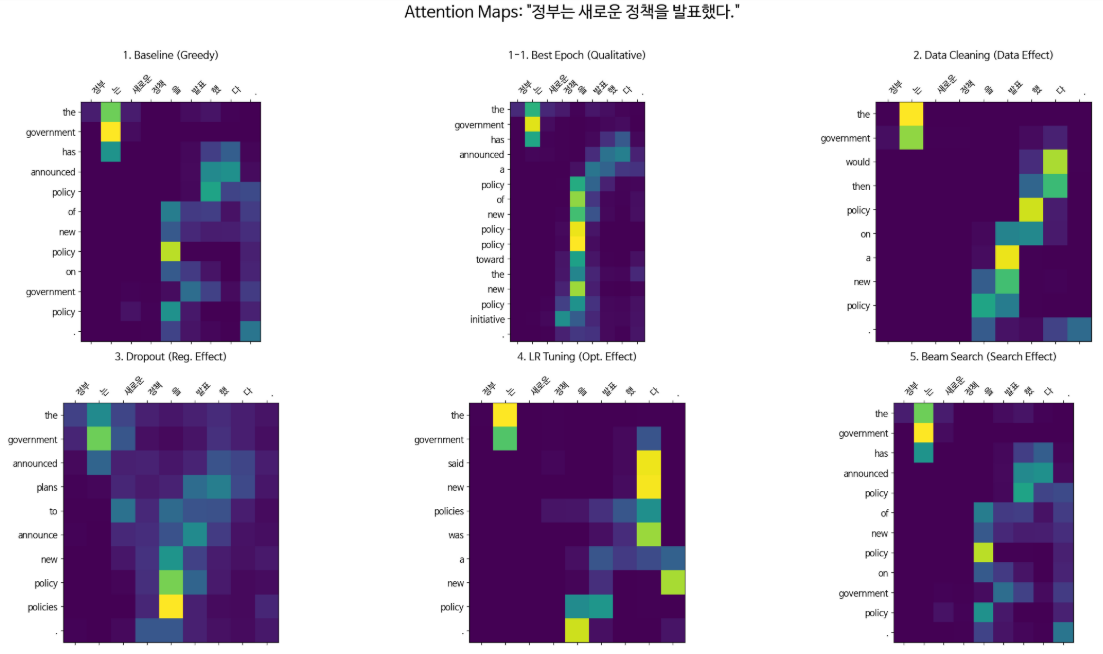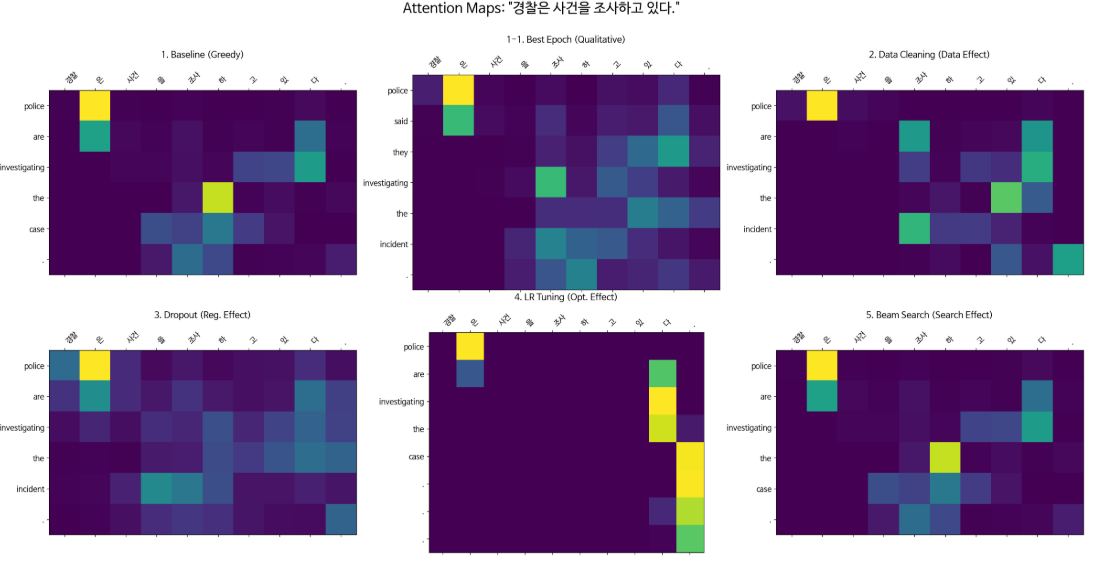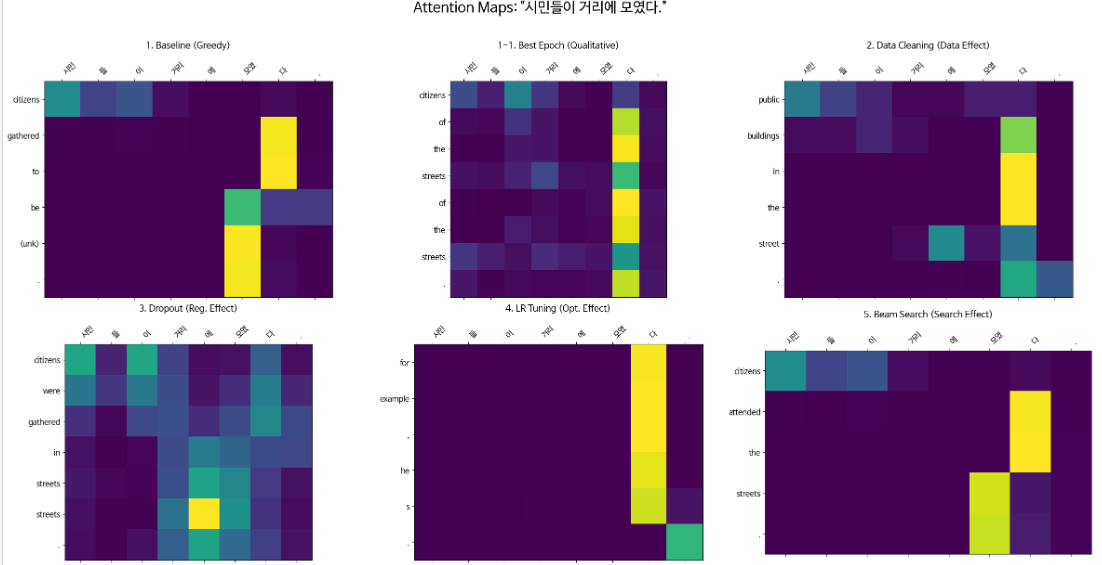

- **여전히 전반적으로 마침표나 조사 부근에 vertical banding이 생성되는 모습이 관찰되었다.**
  **특히, lr tuning 모델이 가장 심각했다.**
  - 왜 이런 결과가 나왔을지 찾아보니  
    **보폭이 너무 작아진 모델이 학습 초기에 가장 쉬운 패턴에 빠져 그 함정을 빠져나올 만큼 충분한 기울기 추진력을 얻지 못했을 수 있다고 한다**
  - 번외로, 수직띠가 무조건 안좋은 것은 아니라고 한다.
     - 한국어의 언어적 특성(교착어)이 반영된 결과로 볼 수도 있다고 함.
       한국어의 조사는 문장 내 단어의 역할을 결정하므로 영어 디코더가 문장 구조를 잡기 위해 조사 토큰을 전역 문맥의 허브처럼 참조하고 있을 가능성이 있음
- **번역결과와 마찬가지로, beam search모델은 baseline과 거의 유사한 attention map을 그려냈고,**
  - beam search는 모델의 가중치나 어텐션 메커니즘을 학습시키는 기법이 아니라, 모델의 추론 과정에서 탐색 경로만 넓히는 알고리즘이라서 이론적으로 매우 타당한 결과라고 한다
  - 추가적으로, 두 결과가 동일하다는 것은 '**현재 모델이 특정 단어를 예측할 때 확률 분포가 매우 뾰족하게 쏠려있다**'는 의미라고 함.  
    이미 모델이 특정 단어에 너무 강한 확신을 가지고 있어서 beam search로 넓게 다른 후보군을 탐색하더라도 결국 greedy한 후보를 이기지 못한 것.
- **가장 좋은 attention map을 보인 것은 dropout 모델이었다.**
  - **'시민들은 도시 속에 산다'라는 문장에서 dropout적용 모델이 가장 좋은 번역을 보여줬는데 attention map에서도 best epoch, beamm search와 같이 다른 모델에 비해서 좋은 모습을 보여주었다. (얼추 대각선 모양으로 히트맵이 그려짐)**
    - 이런 대각선 형태의 히트맵은 모델이 입력과 출력 단어 간의 순차적 대응 관계를 제대로 학습했다는 증거인 **monotonic alignment 단조 정렬 현상**이라고 함
  - **'커피는 필요 없다'의 경우에도 dropout 모델만 유일하게 `coffee-커피`에 약하게라도 attention이 나타났다.**
- **특히 baseline, dropout, beam search에서 citizen-시민의 attention이 나타났다**
- **best epoch모델의 경우 `cities-도시`의 attention이 발견되었다.**
  - 또한, **best epoch 모델도 baseline과 비교하였을 때 확실히 attention map이 더 잘 그려지는 모습을 보임.**

#### 5. 결론
**위에 내용을 거의 다 정리하면 깨달은 점만 짧게 덧붙이겠다.**  
**추가 실험을 통해 얻은 loss, 번역 성능, attention map 세가지 관찰점이 다 같은 결과를 보이지 않는다는 점이 주목할 점인 것 같다.**  
- **loss가 가장 낮았던 데이터 정제모델은 번역 성능과 attention map에서 모두 안 좋은 결과를 보였고**
- **loss가 가장 높았던 dropout 모델은 attention map에서는 가장 좋은 결과를 보였지만, 번역 성능은 특정 문장을 제외하고 완벽하지 않았다.**
  - **그래서, loss와 달리 attention map, 번역 성능의 상관관계는 분명히 존재하겠지만 테스트 문장에 따라 성능이 달라서 정비례한다고 보기는 어렵다.**

**또한, 데이터의 도메인 특성이 잘 드러나는 실험이었다.** 
- **뉴스에 자주 나오는 주제의 경우 모든 모델이 잘 번역하였고, 잘 나오지 않는 주제에 대해서는 의미조차 근접하지 못했다.**

### 회고

**Keep**  
  - 다양한 ablation study 시도
  - 정성 결과에 따른 best epoch 찾아보기
  - 결과에 대한 원인 분석

**Problem**  
  - 다른 추가실험에 대해서도 best epoch을 찾아서 그 시점의 attention map을 봤으면 더 좋았을 것 같다

**Try**  
  - attention 방식 변경(루옹 어텐션)
  - 데이터셋 보완
  - dropout 모델 epoch수 늘려서 학습